In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [2]:
import pandas as pd

# Load first csv file
df_german = pd.read_csv('german_data.csv')
#View data 
df_german.head()

,status of checking account,duration in month,credit history,purpose,credit amount,savings account/bonds,present employment since,installment rate in percentage,personal status and sex,other debtors / guarantors,...,property,age,other installment plans,housing,number of existing credits,job,no of people being liable,telephone,foreign worker,class
0,x < 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,x >= 7 years,4,male:single,none,...,real estate,67,none,own,2,skilled employee/official,1,"yes, registered under the customers name",yes,1
1,0 <= x < 200 DM,48,existing credits paid back duly till now,radio/television,5951,x < 100 DM,1 <= x < 4 years,2,female:divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,none,yes,2
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,x < 100 DM,4 <= x < 7 years,2,male:single,none,...,real estate,49,none,own,1,unskilled-resident,2,none,yes,1
3,x < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,x < 100 DM,4 <= x < 7 years,2,male:single,guarantor,...,if not A121:building society savings agreement...,45,none,for free,1,skilled employee/official,2,none,yes,1
4,x < 0 DM,24,delay in paying off in the past,car (new),4870,x < 100 DM,1 <= x < 4 years,3,male:single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,none,yes,2


In [3]:
df_german.shape

(1000, 21)

In [4]:
df_german.isnull().sum()

status of checking account        0
duration in month                 0
credit history                    0
purpose                           0
credit amount                     0
savings account/bonds             0
present employment since          0
installment rate in percentage    0
personal status and sex           0
other debtors / guarantors        0
present residence since           0
property                          0
age                               0
other installment plans           0
housing                           0
number of existing credits        0
job                               0
no of people being liable         0
telephone                         0
foreign worker                    0
class                             0
dtype: int64

In [5]:
#'our target is are they good or bad customer

In [6]:
df_german.dtypes

status of checking account        object
duration in month                  int64
credit history                    object
purpose                           object
credit amount                      int64
savings account/bonds             object
present employment since          object
installment rate in percentage     int64
personal status and sex           object
other debtors / guarantors        object
present residence since            int64
property                          object
age                                int64
other installment plans           object
housing                           object
number of existing credits         int64
job                               object
no of people being liable          int64
telephone                         object
foreign worker                    object
class                              int64
dtype: object

In [7]:
df_german_FE=df_german.copy()

In [8]:
df_german_FE

,status of checking account,duration in month,credit history,purpose,credit amount,savings account/bonds,present employment since,installment rate in percentage,personal status and sex,other debtors / guarantors,...,property,age,other installment plans,housing,number of existing credits,job,no of people being liable,telephone,foreign worker,class
0,x < 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,x >= 7 years,4,male:single,none,...,real estate,67,none,own,2,skilled employee/official,1,"yes, registered under the customers name",yes,1
1,0 <= x < 200 DM,48,existing credits paid back duly till now,radio/television,5951,x < 100 DM,1 <= x < 4 years,2,female:divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee/official,1,none,yes,2
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,x < 100 DM,4 <= x < 7 years,2,male:single,none,...,real estate,49,none,own,1,unskilled-resident,2,none,yes,1
3,x < 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,x < 100 DM,4 <= x < 7 years,2,male:single,guarantor,...,if not A121:building society savings agreement...,45,none,for free,1,skilled employee/official,2,none,yes,1
4,x < 0 DM,24,delay in paying off in the past,car (new),4870,x < 100 DM,1 <= x < 4 years,3,male:single,none,...,unknown/no property,53,none,for free,2,skilled employee/official,2,none,yes,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,x < 100 DM,4 <= x < 7 years,3,female:divorced/separated/married,none,...,real estate,31,none,own,1,unskilled-resident,1,none,yes,1
996,x < 0 DM,30,existing credits paid back duly till now,car (used),3857,x < 100 DM,1 <= x < 4 years,4,male:divorced/separated,none,...,if not A121:building society savings agreement...,40,none,own,1,management/self-employed/highly qualified empl...,1,"yes, registered under the customers name",yes,1
997,no checking account,12,existing credits paid back duly till now,radio/television,804,x < 100 DM,x >= 7 years,4,male:single,none,...,car or other,38,none,own,1,skilled employee/official,1,none,yes,1
998,x < 0 DM,45,existing credits paid back duly till now,radio/television,1845,x < 100 DM,1 <= x < 4 years,4,male:single,none,...,unknown/no property,23,none,for free,1,skilled employee/official,1,"yes, registered under the customers name",yes,2


In [9]:
df_german['status of checking account'].unique()

array(['x < 0 DM', '0 <= x < 200 DM', 'no checking account',
       'x >= 200 DM_salary assignments for at least 1 year'], dtype=object)

#### <a id='toc1_1_1_2_'></a>[Label Encoding](#toc0_)

In [10]:
#Label Encoding

status_account_map = {'no checking account':0,'x < 0 DM': 1, '0 <= x < 200 DM': 2,'x >= 200 DM_salary assignments for at least 1 year':3}
df_german_FE['status of checking account'] = df_german_FE['status of checking account'].replace(status_account_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/2045529886.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['status of checking account'] = df_german_FE['status of checking account'].replace(status_account_map).astype(int)


In [11]:
df_german['credit history'].unique()

array(['critical account/ other credits existing (not at this bank)',
       'existing credits paid back duly till now',
       'delay in paying off in the past',
       'no credits taken/ all credits paid back duly',
       'all credits at this bank paid back duly'], dtype=object)

In [12]:
#Label Encoding
credit_history_map = {'delay in paying off in the past': -1,'critical account/ other credits existing (not at this bank)':0,'existing credits paid back duly till now': 1,'all credits at this bank paid back duly':2,'no credits taken/ all credits paid back duly':3}
df_german_FE['credit history'] = df_german_FE['credit history'].replace(credit_history_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/3566391892.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['credit history'] = df_german_FE['credit history'].replace(credit_history_map).astype(int)


In [13]:
df_german['purpose'].unique()

array(['radio/television', 'education', 'furniture/equipment',
       'car (new)', 'car (used)', 'business', 'domestic appliances',
       'repairs', 'others', 'retraining'], dtype=object)

In [14]:
#Label Encoding
purpose_map = {'radio/television':1,'furniture/equipment': 2,'domestic appliances':3,'repairs':4,'retraining':5,'education': 6, 'car (used)':7,'car (new)':8,'business':9,'others':10}
df_german_FE['purpose'] = df_german_FE['purpose'].replace(purpose_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/3386006834.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['purpose'] = df_german_FE['purpose'].replace(purpose_map).astype(int)


In [15]:
df_german['savings account/bonds'].unique()

array(['unknown/ no savings account', 'x <  100 DM', '500 <= x < 1000 DM',
       'x >= 1000 DM', '100 <= x <  500 DM'], dtype=object)

In [16]:
#Label Encoding
saving_map = {'unknown/ no savings account':0,'x <  100 DM': 1,'100 <= x <  500 DM':2,'500 <= x < 1000 DM': 3,'x >= 1000 DM':4}
df_german_FE['savings account/bonds'] = df_german_FE['savings account/bonds'].replace(saving_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/817670977.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['savings account/bonds'] = df_german_FE['savings account/bonds'].replace(saving_map).astype(int)


In [17]:
df_german['present employment since'].unique()

array(['x >= 7 years', '1  <= x < 4 years', '4  <= x < 7 years',
       'unemployed', ' x < 1 year'], dtype=object)

In [18]:
#Label Encoding
employment_map = {'unemployed':0, ' x < 1 year':1,'1  <= x < 4 years':2, '4  <= x < 7 years':3,'x >= 7 years':4}
df_german_FE['present employment since'] = df_german_FE['present employment since'].replace(employment_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/1397590355.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['present employment since'] = df_german_FE['present employment since'].replace(employment_map).astype(int)


In [19]:
df_german['personal status and sex'].unique()

array(['male:single', 'female:divorced/separated/married',
       'male:divorced/separated', 'male:married/widowed'], dtype=object)

In [20]:
#Label Encoding
personal_status_map = {'male:single':1,'female:divorced/separated/married': 2, 'male:divorced/separated': 3,'male:married/widowed':4}
df_german_FE['personal status and sex'] = df_german_FE['personal status and sex'].replace(personal_status_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/4091995391.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['personal status and sex'] = df_german_FE['personal status and sex'].replace(personal_status_map).astype(int)


In [21]:
df_german['other debtors / guarantors'].unique()

array(['none', 'guarantor', 'co-applicant'], dtype=object)

In [22]:
#Label Encoding
guarantors_map = {'none':0,'guarantor': 1, 'co-applicant': 2}
df_german_FE['other debtors / guarantors'] = df_german_FE['other debtors / guarantors'].replace(guarantors_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/3426154798.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['other debtors / guarantors'] = df_german_FE['other debtors / guarantors'].replace(guarantors_map).astype(int)


In [23]:
df_german['property'].unique()

array(['real estate',
       'if not A121:building society savings agreement/life insurance',
       'unknown/no property', 'car or other'], dtype=object)

In [24]:
#Label Encoding
property_map = {'unknown/no property':0,'car or other': 1,'if not A121:building society savings agreement/life insurance': 2,'real estate':3}
df_german_FE['property'] = df_german_FE['property'].replace(property_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/3342312040.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['property'] = df_german_FE['property'].replace(property_map).astype(int)


In [25]:
df_german['other installment plans'].unique()

array(['none', 'bank', 'stores'], dtype=object)

In [26]:
#Label Encoding
installment_map = {'none':0,'stores':1,'bank': 2}
df_german_FE['property'] = df_german_FE['property'].replace(installment_map).astype(int)

In [27]:
df_german['housing'].unique()

array(['own', 'for free', 'rent'], dtype=object)

In [28]:
#Label Encoding
housing_map = {'rent':0,'for free':1,'own':2}
df_german_FE['housing'] = df_german_FE['housing'].replace(housing_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/523422740.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['housing'] = df_german_FE['housing'].replace(housing_map).astype(int)


In [29]:
df_german['job'].unique()

array(['skilled employee/official', 'unskilled-resident',
       'management/self-employed/highly qualified employee/ officer',
       'unemployed/unskilled-non-resident'], dtype=object)

In [30]:
#Label Encoding
job_map = {'unemployed/unskilled-non-resident':-1,'unskilled-resident':0,'management/self-employed/highly qualified employee/ officer': 1,'skilled employee/official':3}
df_german_FE['job'] = df_german_FE['job'].replace(job_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/3072105870.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['job'] = df_german_FE['job'].replace(job_map).astype(int)


In [31]:
df_german['telephone'].unique()

array(['yes, registered under the customers name', 'none'], dtype=object)

In [32]:
#Label Encoding
telephone_map = {'none':0,'yes, registered under the customers name': 1}
df_german_FE['telephone'] = df_german_FE['telephone'].replace(telephone_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/4109219910.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['telephone'] = df_german_FE['telephone'].replace(telephone_map).astype(int)


In [33]:
df_german['foreign worker'].unique()

array(['yes', 'no'], dtype=object)

In [34]:
#Label Encoding
worker_map = {'yes':1,'no': 2}
df_german_FE['foreign worker'] = df_german_FE['foreign worker'].replace(worker_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/1460225603.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['foreign worker'] = df_german_FE['foreign worker'].replace(worker_map).astype(int)


In [35]:
#Label Encoding
installment_map = {'none':0,'stores':1,'bank': 2}
df_german_FE['other installment plans'] = df_german_FE['other installment plans'].replace(installment_map).astype(int)

/var/folders/9h/47m7r7s90_g8yb96thpzxb0h0000gn/T/ipykernel_15090/471901734.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_german_FE['other installment plans'] = df_german_FE['other installment plans'].replace(installment_map).astype(int)


In [36]:
df_german_FE

,status of checking account,duration in month,credit history,purpose,credit amount,savings account/bonds,present employment since,installment rate in percentage,personal status and sex,other debtors / guarantors,...,property,age,other installment plans,housing,number of existing credits,job,no of people being liable,telephone,foreign worker,class
0,1,6,0,1,1169,0,4,4,1,0,...,3,67,0,2,2,3,1,1,1,1
1,2,48,1,1,5951,1,2,2,2,0,...,3,22,0,2,1,3,1,0,1,2
2,0,12,0,6,2096,1,3,2,1,0,...,3,49,0,2,1,0,2,0,1,1
3,1,42,1,2,7882,1,3,2,1,1,...,2,45,0,1,1,3,2,0,1,1
4,1,24,-1,8,4870,1,2,3,1,0,...,0,53,0,1,2,3,2,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,12,1,2,1736,1,3,3,2,0,...,3,31,0,2,1,0,1,0,1,1
996,1,30,1,7,3857,1,2,4,3,0,...,2,40,0,2,1,1,1,1,1,1
997,0,12,1,1,804,1,4,4,1,0,...,1,38,0,2,1,3,1,0,1,1
998,1,45,1,1,1845,1,2,4,1,0,...,0,23,0,1,1,3,1,1,1,2


In [37]:
df_german_FE["class"].value_counts()

class
1    700
2    300
Name: count, dtype: int64

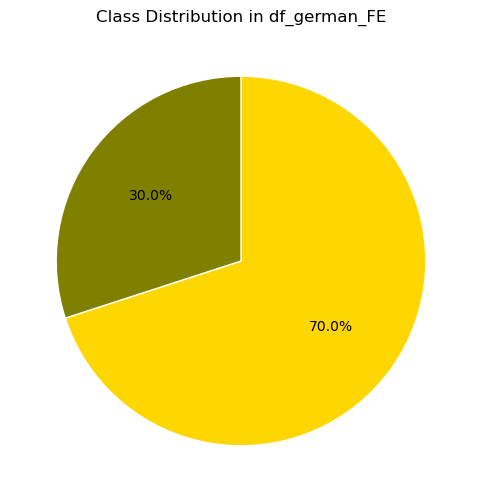

In [38]:
import matplotlib.pyplot as plt

# Value counts
class_counts = df_german_FE["class"].value_counts()

# Plot pie chart with percentage labels
plt.figure(figsize=(6,6))
plt.pie(
    class_counts, 
    autopct="%1.1f%%",    # show percentage with 1 decimal
    startangle=90,        # rotate start
    counterclock=False,
    colors=["gold", "olive"],
    wedgeprops={"edgecolor": "white"}  # black outline
)

plt.title("Class Distribution in df_german_FE")
plt.show()



imbalanced data (data set not represented equally)


#### <a id='toc1_1_1_2_'></a>[Train Test Split](#toc0_)


In [39]:
from sklearn.model_selection import train_test_split
X, y = df_german_FE.drop(columns=['class']), df_german_FE['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=15) #Creating an instance of the model

knn.fit(X_train, y_train) # Training the model

KNeighborsClassifier(n_neighbors=15)

In [41]:
pred = knn.predict(X_test) #predictions for new data points

In [42]:
knn.score(X_test, y_test)# evaluating the model using score to get the accuracy

0.69

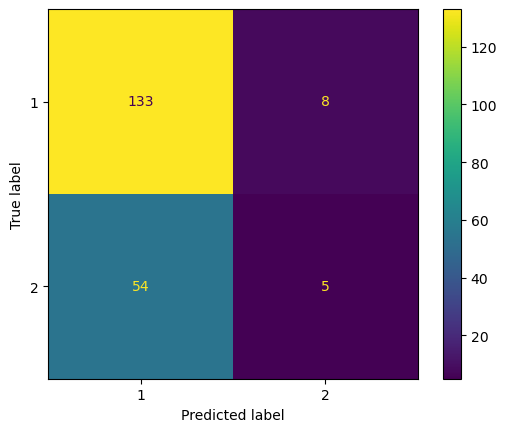

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_matrix(y_true=y_test, y_pred=knn.predict(X_test))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=knn.predict(X_test))

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=knn.predict(X_test)))

              precision    recall  f1-score   support

           1       0.71      0.94      0.81       141
           2       0.38      0.08      0.14        59

    accuracy                           0.69       200
   macro avg       0.55      0.51      0.47       200
weighted avg       0.61      0.69      0.61       200



-  Class 0 is well predicted: High precision and recall indicate the model is very effective at identifying bad costumers.
-  Class 1 is poorly predicted: Low recall (8%) means the model misses most bad costumers, and the low F1-score (14%) confirms weak performance on this minority class.

In [45]:
# Probabilities for AUC (positive class)
y_proba_knn = knn.predict_proba(X_test)[:, 1]

# Calculate metrics
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
auc = roc_auc_score(y_test, y_proba_knn)

# Display results
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.7112
Recall    : 0.9433
F1 Score  : 0.8110


#### Logistic Regression

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Train model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Predict
y_pred = logreg.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
# Predictions
y_pred = logreg.predict(X_test)

# Probabilities for AUC
y_proba = logreg.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

# Display results
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")

              precision    recall  f1-score   support

           1       0.75      0.87      0.80       141
           2       0.49      0.31      0.38        59

    accuracy                           0.70       200
   macro avg       0.62      0.59      0.59       200
weighted avg       0.67      0.70      0.68       200

[[122  19]
 [ 41  18]]
Accuracy  : 0.7000
Precision : 0.7485
Recall    : 0.8652
F1 Score  : 0.8026
AUC       : 0.6609


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create and train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

rf.fit(X_train, y_train)

# Accuracy on training set
train_acc = accuracy_score(y_train, rf.predict(X_train))

# Accuracy on test set
test_acc = accuracy_score(y_test, rf.predict(X_test))

print("Training Accuracy:", train_acc) #0.81
print("Test Accuracy:", test_acc) # 0.76
print("Random forste results", classification_report(y_test, y_pred))

# Predictions
y_pred = rf.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

# Display results
print("Random Forest results")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Training Accuracy: 0.81125
Test Accuracy: 0.755
Random forste results               precision    recall  f1-score   support

           1       0.75      0.87      0.80       141
           2       0.49      0.31      0.38        59

    accuracy                           0.70       200
   macro avg       0.62      0.59      0.59       200
weighted avg       0.67      0.70      0.68       200

Random Forest results
Accuracy  : 0.7550
Precision : 0.7527
Recall    : 0.9716
F1 Score  : 0.8483


####Gradient Boosting

              precision    recall  f1-score   support

           1       0.82      0.91      0.86       141
           2       0.70      0.51      0.59        59

    accuracy                           0.79       200
   macro avg       0.76      0.71      0.72       200
weighted avg       0.78      0.79      0.78       200

F1 Score     : 0.8591
Recall       : 0.9078
Precision    : 0.8153
AUC          : 0.6609


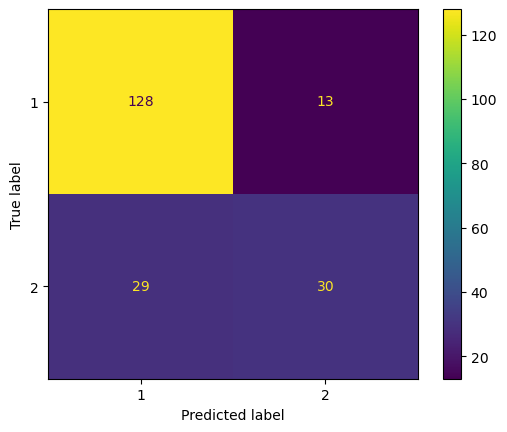

In [48]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(max_depth=5, n_estimators=100)
gb.fit(X_train, y_train)

# Train model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

gb_model.fit(X_train, y_train)

# Predict
y_pred = gb_model.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= gb_model.predict(X_test))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= gb_model.predict(X_test))

# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_gb = logreg.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba_gb)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

#### <a id='toc1_1_1_3_'></a>[Normalization](#toc0_)

In [49]:
from sklearn.preprocessing import MinMaxScaler

# Create an instance of the normalizer
minmax = MinMaxScaler() 
#Fit it to our training data
minmax.fit(X_train)

MinMaxScaler()

In [50]:
#Transforming our training and testing data
X_train_transformed = minmax.transform(X_train)
X_test_transformed = minmax.transform(X_test)
# we do this because when applying transformations of our dataframe, normalizer will return an array instead of a dataframe object
X_train_transformed = pd.DataFrame(minmax.transform(X_train))
X_test_transformed = pd.DataFrame(minmax.transform(X_test))
X_train_transformed

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.333333,1.000000,0.00,0.888889,0.362386,0.25,1.00,0.666667,0.000000,0.0,1.000000,0.000000,0.785714,0.0,1.0,0.333333,1.0,0.0,1.0,0.0
1,1.000000,0.303571,0.25,0.555556,0.113844,0.25,0.25,0.333333,0.666667,0.0,0.000000,0.333333,0.250000,0.0,0.0,0.000000,1.0,0.0,0.0,0.0
2,0.000000,0.035714,0.50,0.666667,0.054253,0.75,0.50,0.333333,0.000000,0.0,1.000000,0.666667,0.553571,0.0,0.0,0.000000,1.0,0.0,0.0,0.0
3,0.000000,0.303571,1.00,0.777778,0.261527,0.00,0.50,0.000000,0.333333,0.0,1.000000,0.666667,0.178571,1.0,1.0,0.333333,1.0,0.0,1.0,0.0
4,0.000000,0.142857,0.50,0.000000,0.034995,0.00,0.50,1.000000,0.333333,0.0,0.333333,0.333333,0.035714,0.0,1.0,0.000000,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0.000000,0.250000,0.75,0.777778,0.341587,0.25,1.00,0.333333,0.000000,0.0,1.000000,0.000000,0.357143,1.0,1.0,0.333333,0.5,1.0,1.0,0.0
796,0.000000,0.250000,0.50,0.777778,0.132717,0.00,0.75,1.000000,0.000000,0.0,0.666667,0.666667,0.232143,0.0,1.0,0.000000,1.0,0.0,0.0,1.0
797,0.000000,0.357143,0.25,0.666667,0.305601,1.00,0.50,1.000000,0.000000,0.0,0.333333,1.000000,0.142857,0.0,1.0,0.333333,1.0,0.0,0.0,0.0
798,0.666667,0.142857,0.50,0.000000,0.067899,0.00,0.50,0.333333,1.000000,0.0,0.000000,1.000000,0.107143,0.0,1.0,0.000000,1.0,0.0,1.0,0.0


In [51]:
X_train_transformed = pd.DataFrame(minmax.transform(X_train), columns=X_train.columns)
X_test_transformed = pd.DataFrame(minmax.transform(X_test), columns=X_train.columns)
X_test_transformed

,status of checking account,duration in month,credit history,purpose,credit amount,savings account/bonds,present employment since,installment rate in percentage,personal status and sex,other debtors / guarantors,present residence since,property,age,other installment plans,housing,number of existing credits,job,no of people being liable,telephone,foreign worker
0,0.333333,0.250000,0.50,0.000000,0.161770,0.25,0.50,0.333333,0.333333,0.0,0.333333,1.000000,0.089286,0.0,1.0,0.000000,1.00,0.0,0.0,0.0
1,0.333333,0.250000,0.50,0.777778,0.227248,0.50,0.50,0.666667,0.000000,0.0,1.000000,0.333333,0.285714,0.0,1.0,0.000000,0.25,1.0,1.0,0.0
2,0.333333,0.357143,0.75,0.777778,0.114174,0.50,0.75,0.333333,0.000000,0.0,0.666667,0.333333,0.232143,1.0,1.0,0.000000,1.00,0.0,0.0,0.0
3,1.000000,0.142857,0.50,0.000000,0.057610,0.25,0.50,0.666667,1.000000,0.0,1.000000,1.000000,0.071429,0.0,0.0,0.000000,1.00,0.0,0.0,0.0
4,0.000000,0.517857,0.25,0.666667,0.385331,0.25,0.75,0.666667,0.000000,0.0,0.333333,0.333333,0.285714,0.0,1.0,0.333333,0.50,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.000000,0.357143,0.50,0.000000,0.164246,0.75,1.00,0.666667,0.666667,0.0,0.333333,0.333333,0.125000,0.0,1.0,0.000000,0.50,0.0,1.0,0.0
196,0.666667,1.000000,0.50,0.777778,0.393859,0.50,0.25,1.000000,0.333333,0.0,0.333333,0.666667,0.089286,0.0,1.0,0.000000,0.50,0.0,0.0,0.0
197,0.333333,0.357143,0.50,0.888889,0.347639,0.25,0.50,0.333333,1.000000,0.0,0.333333,0.333333,0.035714,0.5,1.0,0.000000,0.25,0.0,0.0,0.0
198,0.333333,0.357143,0.75,0.666667,0.186090,0.25,0.50,0.000000,0.333333,0.5,1.000000,0.333333,0.053571,1.0,0.0,0.000000,1.00,0.0,0.0,1.0


In [52]:
knn = KNeighborsClassifier(n_neighbors=15) #Creating an instance of the model

knn.fit(X_train_transformed, y_train) # Training the model

KNeighborsClassifier(n_neighbors=15)

In [53]:
pred = knn.predict(X_test_transformed) #predictions for new data points

In [54]:
knn.score(X_test_transformed, y_test)# evaluating the model using score to get the accuracy

0.72

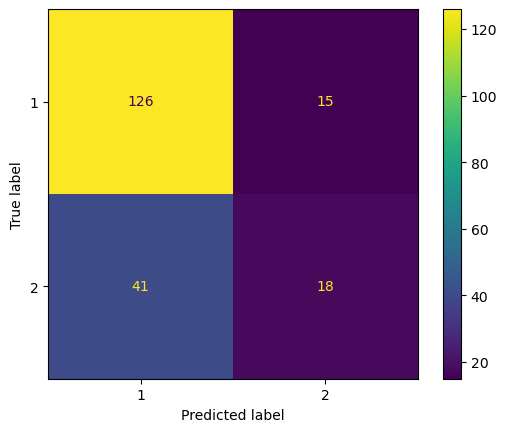

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confusion_matrix(y_true=y_test, y_pred=knn.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=knn.predict(X_test_transformed))

In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=knn.predict(X_test_transformed)))


              precision    recall  f1-score   support

           1       0.75      0.89      0.82       141
           2       0.55      0.31      0.39        59

    accuracy                           0.72       200
   macro avg       0.65      0.60      0.60       200
weighted avg       0.69      0.72      0.69       200



In [57]:
# Probabilities for AUC (positive class)
y_proba_knn = knn.predict_proba(X_test_transformed)[:, 1]

# Calculate metrics
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
auc = roc_auc_score(y_test, y_proba_knn)

# Display results
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.7545
Recall    : 0.8936
F1 Score  : 0.8182


-  Class 0 remains strong: High precision and recall confirm reliable identification of bed consumers.
-  Class 1 shows significant improvement:
- Precision increased from 0.38 → 0.70
- Recall increased from 0.11 → 0.3
- F1-score increased from 0.17 → 0.47
This means the model is now better at identifying actual defaulters, with fewer false negatives.

## <a id='toc1_3_'></a>[Feature Selection](#toc0_)

In [58]:
df_german_FE.corr()

,status of checking account,duration in month,credit history,purpose,credit amount,savings account/bonds,present employment since,installment rate in percentage,personal status and sex,other debtors / guarantors,...,property,age,other installment plans,housing,number of existing credits,job,no of people being liable,telephone,foreign worker,class
status of checking account,1.000000,0.035050,0.119639,0.022674,0.024561,-0.005614,-0.108536,-0.057942,0.069946,0.041970,...,-0.021554,-0.049058,0.045471,-0.032925,-0.093081,-0.092585,-0.040889,-0.039209,-0.000205,0.197788
duration in month,0.035050,1.000000,0.012071,0.112279,0.624984,-0.064526,0.057381,0.074749,-0.116029,0.006711,...,-0.303971,-0.036136,0.054884,-0.011950,-0.011284,0.103950,-0.023834,0.164718,-0.138196,0.214927
credit history,0.119639,0.012071,1.000000,-0.011496,0.015892,-0.005299,-0.094856,-0.029329,0.049031,0.043305,...,-0.040710,-0.103926,0.111382,-0.099253,-0.331807,-0.013589,-0.017043,-0.058436,0.022071,0.187921
purpose,0.022674,0.112279,-0.011496,1.000000,0.214874,-0.001733,-0.003486,-0.104617,-0.081533,-0.052961,...,-0.114760,0.120267,0.079821,-0.044829,0.089404,-0.119956,0.132098,0.132286,0.078793,0.092162
credit amount,0.024561,0.624984,0.015892,0.214874,1.000000,-0.107538,-0.008367,-0.271316,-0.159434,0.037921,...,-0.311599,0.032716,0.046008,-0.056119,0.020795,-0.012414,0.017142,0.276995,-0.050050,0.154739
savings account/bonds,-0.005614,-0.064526,-0.005299,-0.001733,-0.107538,1.000000,0.014600,-0.000805,0.062953,-0.047575,...,0.025651,-0.017997,0.000367,-0.003268,-0.004176,0.025595,-0.021302,-0.037452,0.005318,-0.033871
present employment since,-0.108536,0.057381,-0.094856,-0.003486,-0.008367,0.014600,1.000000,0.126161,-0.181745,-0.028758,...,-0.087187,0.256227,0.040154,0.044583,0.125791,0.147797,0.097192,0.060518,-0.027232,-0.116002
installment rate in percentage,-0.057942,0.074749,-0.029329,-0.104617,-0.271316,-0.000805,0.126161,1.000000,-0.081121,-0.014835,...,-0.053391,0.058266,0.000983,0.073955,0.021669,0.067403,-0.071207,0.014413,-0.090024,0.072404
personal status and sex,0.069946,-0.116029,0.049031,-0.081533,-0.159434,0.062953,-0.181745,-0.081121,1.000000,-0.011880,...,0.174494,-0.186563,-0.045598,-0.083146,-0.089640,0.008883,-0.238327,-0.057207,0.009204,0.042643
other debtors / guarantors,0.041970,0.006711,0.043305,-0.052961,0.037921,-0.047575,-0.028758,-0.014835,-0.011880,1.000000,...,0.066303,-0.028294,0.030110,-0.036219,-0.017662,-0.003615,-0.010990,-0.050996,0.107639,0.028441


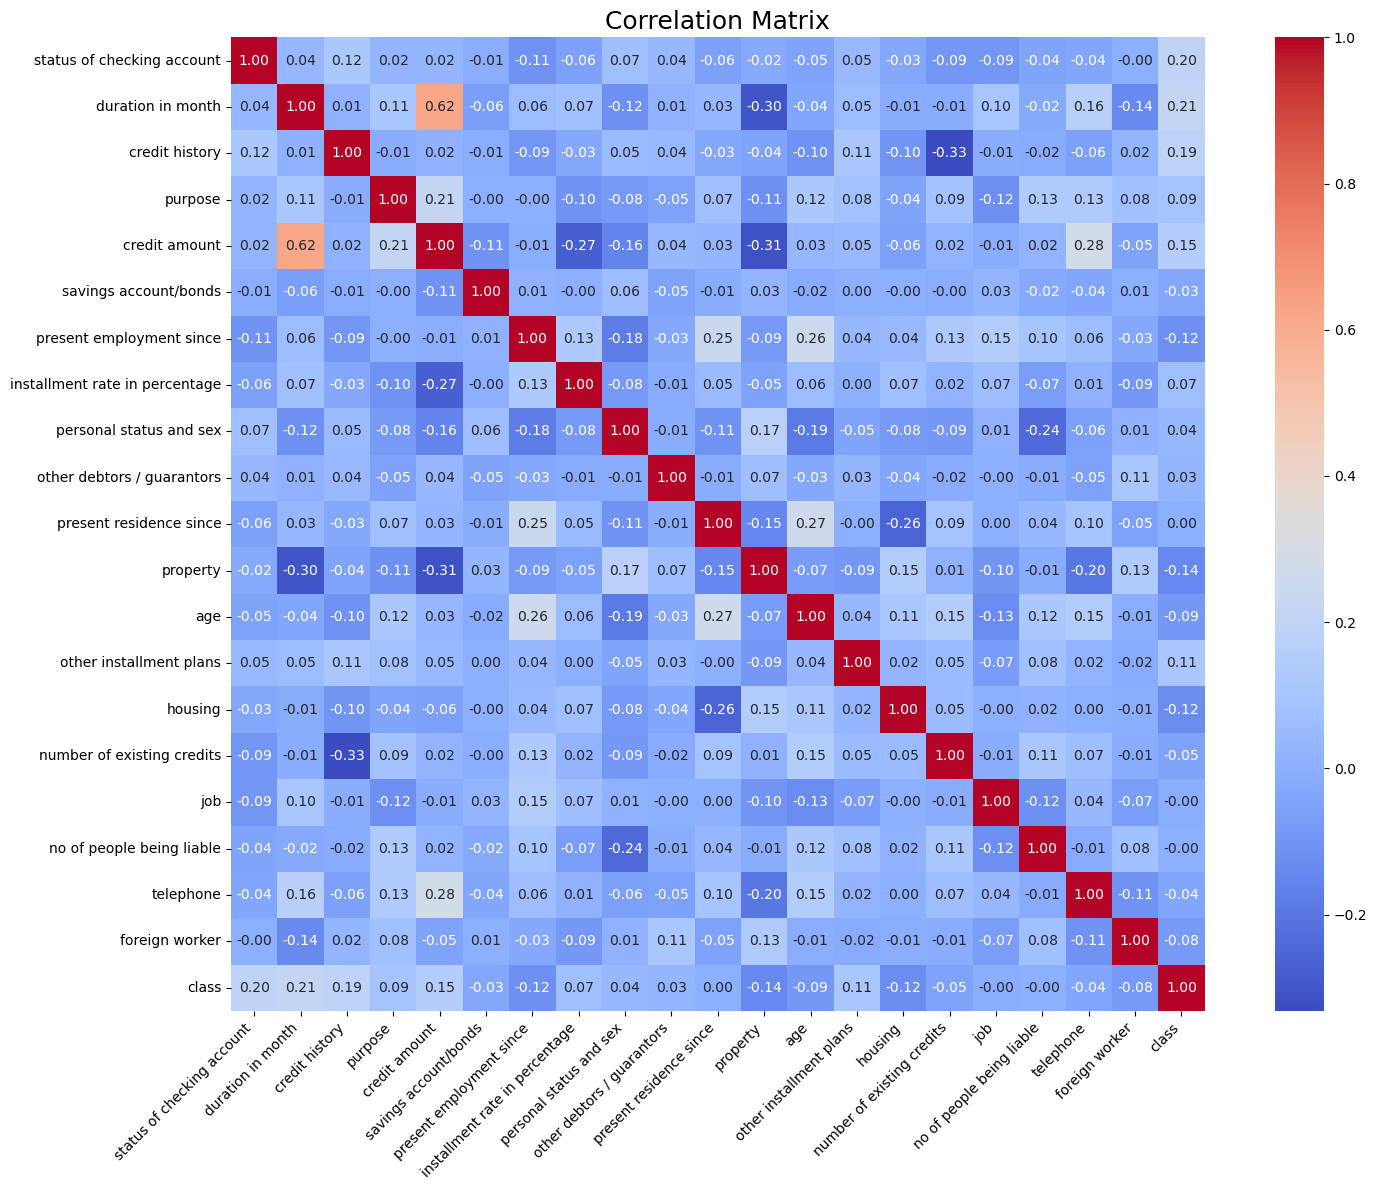

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))  
sns.heatmap(df_german_FE.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [60]:
#Historgams relationship of target with feature
import plotly.express as px 

for col in df_german_FE.columns:
    if col=='class':
        continue
    fig=px.histogram(df_german_FE,x=col,color='class')
    fig.show()


## <a id='toc1_3_'></a>[Logistic regression](#toc0_)

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split



# Train model
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_transformed, y_train)

# Predict
y_pred = logreg.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.75      0.89      0.81       141
           2       0.52      0.29      0.37        59

    accuracy                           0.71       200
   macro avg       0.63      0.59      0.59       200
weighted avg       0.68      0.71      0.68       200

[[125  16]
 [ 42  17]]


In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
# Predictions
y_pred = logreg.predict(X_test_transformed)

# Probabilities for AUC
y_proba = logreg.predict_proba(X_test_transformed)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

# Display results
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")

Accuracy  : 0.7100
Precision : 0.7485
Recall    : 0.8865
F1 Score  : 0.8117
AUC       : 0.6734


## <a id='toc1_3_'></a>[Bagging](#toc0_)

In [63]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [64]:
from sklearn.ensemble import BaggingRegressor
bg_reg = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=10), n_estimators=100)

# Train ensemble
bg_reg.fit(X_test_transformed, y_train)

print("Bagging Accuracy train:",bg_reg.score(X_test_transformed, y_train)) # 0,81

ValueError: Found input variables with inconsistent numbers of samples: [200, 800]

In [ ]:
print("Bagging Accuracy test:",bg_reg.score(X_test_transformed, y_test)) # 0.26

Bagging Accuracy test: 0.2555633709960111


In [ ]:
bg_reg = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=10), n_estimators=10)

# Train ensemble
bg_reg.fit(X_test_transformed, y_train)

print("Bagging Accuracy train set:",bg_reg.score(X_test_transformed, y_train)) # 0.77

Bagging Accuracy train set: 0.785997989771765


In [ ]:
# Evaluate
print("Bagging Accuracy test set:", bg_reg.score(X_test, y_test)) #0.20

Bagging Accuracy test set: 0.23361699772529998


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions
y_pred_train = bg_reg.predict(X_train)
y_pred_test = bg_reg.predict(X_test)

# Metrics for train set
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)

# Metrics for test set
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

# Display results
print("=== Train Set Metrics ===")
print(f"R2      : {r2_train:.4f}")
print(f"MAE     : {mae_train:.4f}")
print(f"MSE     : {mse_train:.4f}")
print(f"RMSE    : {rmse_train:.4f}")

print("\n=== Test Set Metrics ===")
print(f"R2      : {r2_test:.4f}")
print(f"MAE     : {mae_test:.4f}")
print(f"MSE     : {mse_test:.4f}")
print(f"RMSE    : {rmse_test:.4f}")

=== Train Set Metrics ===
R2      : 0.7860
MAE     : 0.1524
MSE     : 0.0450
RMSE    : 0.2122

=== Test Set Metrics ===
R2      : 0.2336
MAE     : 0.3069
MSE     : 0.1594
RMSE    : 0.3992


## <a id='toc1_3_'></a>[Pasting](#toc0_)

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Base model: KNN
knn = KNeighborsClassifier(n_neighbors=15)

# Pasting (bootstrap=False)
pasting = BaggingClassifier(estimator=knn, n_estimators=50, max_samples=0.8, bootstrap=False, random_state=42)

# Train ensemble
pasting.fit(X_train, y_train)

# Evaluate
print("Pasting Accuracy train set:", pasting.score(X_train, y_train)) #0.71
print("Pasting Accuracy test set:", pasting.score(X_test, y_test)) #0.7

Pasting Accuracy train set: 0.70875
Pasting Accuracy test set: 0.7


In [ ]:

# Predictions
y_pred = pasting.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

# Display results
print("Pasting results")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Pasting results
Accuracy  : 0.7000
Precision : 0.7143
Recall    : 0.9574
F1 Score  : 0.8182


## <a id='toc1_3_'></a>[Random Forest](#toc0_)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score
)

# Example: scale features
scaler = StandardScaler()

# Fit scaler on training data only
X_train_transform = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_transform = scaler.transform(X_test)

# Create and train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train_transform, y_train)

# Accuracy on transformed sets
train_acc = accuracy_score(y_train, rf.predict(X_train_transform))
test_acc = accuracy_score(y_test, rf.predict(X_test_transform))

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Predictions
y_pred = rf.predict(X_test_transform)
y_proba = rf.predict_proba(X_test_transform)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

# Display results
print("Random Forest results")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_test, y_pred))

Training Accuracy: 0.81125
Test Accuracy: 0.755
Random Forest results
Accuracy  : 0.7550
Precision : 0.7527
Recall    : 0.9716
F1 Score  : 0.8483
AUC       : 0.7906
Confusion Matrix:
 [[137   4]
 [ 45  14]]
Classification Report:
               precision    recall  f1-score   support

           1       0.75      0.97      0.85       141
           2       0.78      0.24      0.36        59

    accuracy                           0.76       200
   macro avg       0.77      0.60      0.61       200
weighted avg       0.76      0.76      0.71       200



## <a id='toc1_3_'></a>[Gradient Boosting](#toc0_)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score
)

# Create and train Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,    # number of boosting stages
    learning_rate=0.1,   # step size shrinkage
    max_depth=3,         # tree depth
    random_state=42
)

gb.fit(X_train_transform, y_train)

# Accuracy on transformed sets
train_acc = accuracy_score(y_train, gb.predict(X_train_transform))
test_acc = accuracy_score(y_test, gb.predict(X_test_transform))

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Predictions
y_pred = gb.predict(X_test_transform)
y_proba = gb.predict_proba(X_test_transform)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

# Display results
print("Gradient Boosting results")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_test, y_pred))

Training Accuracy: 0.90375
Test Accuracy: 0.79
Gradient Boosting results
Accuracy  : 0.7900
Precision : 0.8153
Recall    : 0.9078
F1 Score  : 0.8591
AUC       : 0.8080
Confusion Matrix:
 [[128  13]
 [ 29  30]]
Classification Report:
               precision    recall  f1-score   support

           1       0.82      0.91      0.86       141
           2       0.70      0.51      0.59        59

    accuracy                           0.79       200
   macro avg       0.76      0.71      0.72       200
weighted avg       0.78      0.79      0.78       200



## <a id='toc1_3_'></a>[AdaBoost](#toc0_)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score
)

# Create and train AdaBoost
ab = AdaBoostClassifier(
    n_estimators=100,    # number of weak learners
    learning_rate=1.0,   # contribution of each weak learner
    random_state=42
)

ab.fit(X_train_transform, y_train)

# Accuracy on transformed sets
train_acc = accuracy_score(y_train, ab.predict(X_train_transform))
test_acc = accuracy_score(y_test, ab.predict(X_test_transform))

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

# Predictions
y_pred = ab.predict(X_test_transform)
y_proba = ab.predict_proba(X_test_transform)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

# Display results
print("AdaBoost results")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC       : {auc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_test, y_pred))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning:

The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.



Training Accuracy: 0.80875
Test Accuracy: 0.78
AdaBoost results
Accuracy  : 0.7800
Precision : 0.8170
Recall    : 0.8865
F1 Score  : 0.8503
AUC       : 0.7809
Confusion Matrix:
 [[125  16]
 [ 28  31]]
Classification Report:
               precision    recall  f1-score   support

           1       0.82      0.89      0.85       141
           2       0.66      0.53      0.58        59

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200



### performance results after normalization

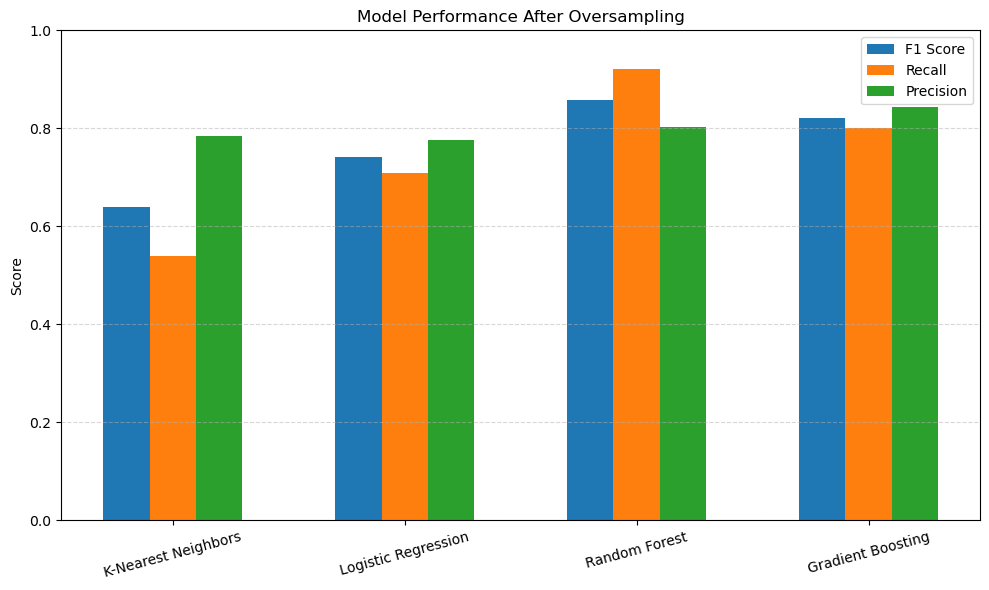

In [ ]:
# Define model performance metrics (post-oversampling)
model_metrics = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6387, 0.7407, 0.8581, 0.8218],
    "Recall": [0.5390, 0.7092, 0.9220, 0.8014],
    "Precision": [0.7835, 0.7752, 0.8025, 0.8433]
}


# Create DataFrame
df_metrics = pd.DataFrame(model_metrics)

# Set figure size
plt.figure(figsize=(10, 6))

# Bar width and positions
bar_width = 0.2
x = range(len(df_metrics["Model"]))

# Plot each metric
plt.bar([i - bar_width for i in x], df_metrics["F1 Score"], width=bar_width, label="F1 Score")
plt.bar(x, df_metrics["Recall"], width=bar_width, label="Recall")
plt.bar([i + bar_width for i in x], df_metrics["Precision"], width=bar_width, label="Precision")

# Customize the plot
plt.xticks(x, df_metrics["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Model Performance After Oversampling")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

## Imbalanced

### Oversampling

In [ ]:
train = pd.DataFrame(X_train_transformed, columns = X_train.columns)
train["class"] = y_train.values

good = train[train["class"] == 1]
bad = train[train["class"] == 2]

In [ ]:
print(train["class"].value_counts())

class
1    559
2    241
Name: count, dtype: int64


In [ ]:
from sklearn.utils import resample
# Oversample the minority class
bad_oversampled = resample(
    bad,
    replace=True,                # Sample with replacement
    n_samples=len(good),   # Match majority class size
    random_state=42              # For reproducibility
)

# Combine with majority class
train_over = pd.concat([good, bad_oversampled])
train_over

,status of checking account,duration in month,credit history,purpose,credit amount,savings account/bonds,present employment since,installment rate in percentage,personal status and sex,other debtors / guarantors,...,property,age,other installment plans,housing,number of existing credits,job,no of people being liable,telephone,foreign worker,class
2,0.000000,0.035714,0.50,0.666667,0.054253,0.75,0.50,0.333333,0.000000,0.0,...,0.666667,0.553571,0.0,0.0,0.000000,1.00,0.0,0.0,0.0,1
4,0.000000,0.142857,0.50,0.000000,0.034995,0.00,0.50,1.000000,0.333333,0.0,...,0.333333,0.035714,0.0,1.0,0.000000,1.00,0.0,0.0,0.0,1
6,0.000000,0.035714,0.50,0.111111,0.150105,0.75,0.50,0.000000,0.000000,0.0,...,0.333333,0.232143,0.0,1.0,0.000000,1.00,0.0,1.0,0.0,1
9,0.000000,0.250000,0.25,0.111111,0.194234,0.25,0.25,0.666667,0.666667,0.0,...,0.333333,0.285714,0.0,1.0,0.333333,0.50,0.0,1.0,0.0,1
10,0.000000,0.410714,0.50,0.333333,0.271817,0.00,1.00,1.000000,0.000000,0.0,...,0.666667,0.517857,0.0,1.0,1.000000,1.00,1.0,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8,0.333333,0.357143,0.50,0.111111,0.151095,0.00,0.50,0.333333,1.000000,0.0,...,0.333333,0.017857,0.0,1.0,0.000000,1.00,0.0,0.0,0.0,2
362,1.000000,0.196429,0.50,0.000000,0.114284,0.25,0.25,0.333333,0.333333,0.0,...,1.000000,0.107143,0.0,1.0,0.000000,0.25,0.0,0.0,0.0,2
749,0.333333,0.142857,0.50,0.777778,0.061737,0.25,0.75,0.333333,0.666667,0.0,...,0.333333,0.303571,0.0,1.0,0.000000,1.00,0.0,0.0,0.0,2
375,0.333333,0.785714,0.50,0.666667,0.552823,0.25,0.75,1.000000,0.000000,0.0,...,0.000000,0.357143,0.5,0.5,0.666667,1.00,1.0,1.0,0.0,2


In [ ]:
print(train_over["class"].value_counts())

class
1    559
2    559
Name: count, dtype: int64


In [ ]:
X_train_over = train_over.drop("class", axis=1)
y_train_over = train_over["class"]

#### KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=15) #Creating an instance of the model

knn.fit(X_train_over, y_train_over) # Training the model

pred = knn.predict(X_test_transformed) #predictions for new data points

knn.score(X_test_transformed, y_test)# evaluating the model using score to get the accuracy

0.57

In [ ]:
print(classification_report(y_true=y_test, y_pred=knn.predict(X_test_transformed)))

              precision    recall  f1-score   support

           1       0.78      0.54      0.64       141
           2       0.37      0.64      0.47        59

    accuracy                           0.57       200
   macro avg       0.58      0.59      0.55       200
weighted avg       0.66      0.57      0.59       200



In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score
# Calculate metrics
f1 = f1_score(y_test, pred)
recall = recall_score(y_test, pred)
precision = precision_score(y_test, pred)

y_proba_knn = knn.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_knn)


# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.6387
Recall       : 0.5390
Precision    : 0.7835
AUC          : 0.6821


#### Logistic regression

              precision    recall  f1-score   support

           1       0.78      0.71      0.74       141
           2       0.42      0.51      0.46        59

    accuracy                           0.65       200
   macro avg       0.60      0.61      0.60       200
weighted avg       0.67      0.65      0.66       200



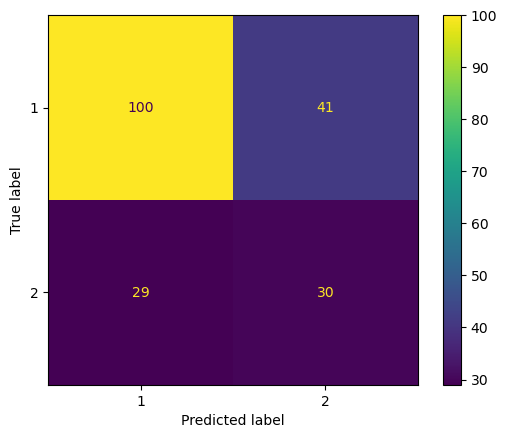

In [ ]:
# Train model
logreg = LogisticRegression(max_iter=1000)


logreg.fit(X_train_over, y_train_over)

# Predict
y_pred = logreg.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))


confusion_matrix(y_true=y_test, y_pred= logreg.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= logreg.predict(X_test_transformed))

In [ ]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_logreg = logreg.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_logreg)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.7407
Recall       : 0.7092
Precision    : 0.7752
AUC          : 0.6724


#### Random Forest

              precision    recall  f1-score   support

           1       0.80      0.92      0.86       141
           2       0.71      0.46      0.56        59

    accuracy                           0.79       200
   macro avg       0.76      0.69      0.71       200
weighted avg       0.78      0.79      0.77       200



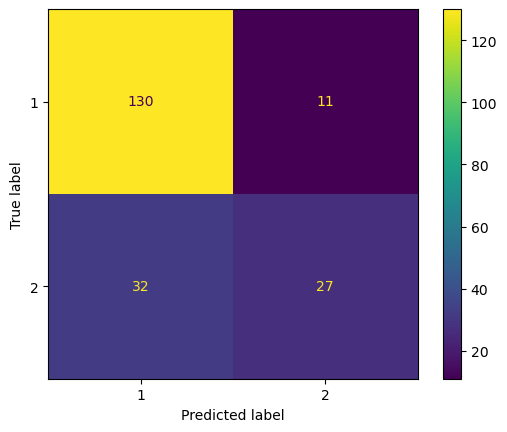

In [ ]:
# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_over, y_train_over)

# Predict
y_pred = rf_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))

In [ ]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_rf = logreg.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_rf)

# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.8581
Recall       : 0.9220
Precision    : 0.8025
AUC          : 0.6724


#### Gradient Boosting

              precision    recall  f1-score   support

           1       0.84      0.80      0.82       141
           2       0.58      0.64      0.61        59

    accuracy                           0.76       200
   macro avg       0.71      0.72      0.71       200
weighted avg       0.76      0.76      0.76       200



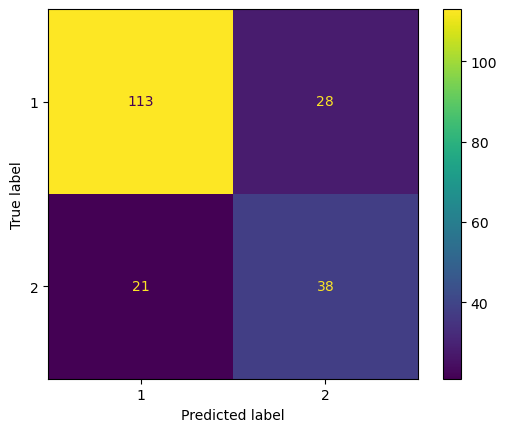

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
# Train model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

gb_model.fit(X_train_over, y_train_over)

# Predict
y_pred = gb_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))

In [ ]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_gb = logreg.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_gb)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.8218
Recall       : 0.8014
Precision    : 0.8433
AUC          : 0.6724


#### Oversampling results

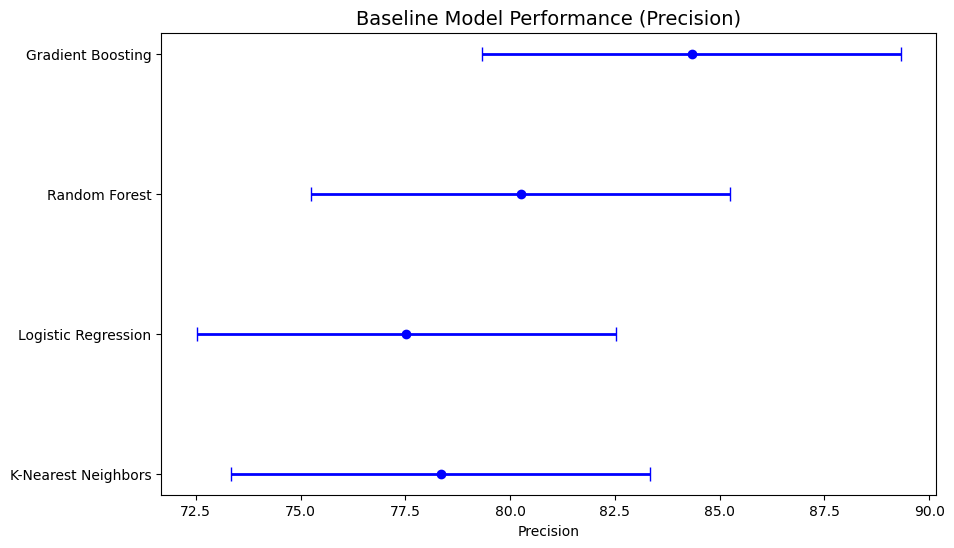

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define model performance metrics (post-oversampling)
model_metrics = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6387, 0.7407, 0.8581, 0.8218],
    "Recall": [0.5390, 0.7092, 0.9220, 0.8014],
    "Precision": [0.7835, 0.7752, 0.8025, 0.8433]
}

# Convert to DataFrame
df_metrics = pd.DataFrame(model_metrics)

# Choose metric to plot
metric = "Precision"

# Mean values (convert to %)
means = df_metrics[metric].values * 100
labels = df_metrics["Model"].values

# Fake symmetric error bars (±5 percentage points)
# must be non-negative, so just use a constant width
error_width = np.full_like(means, 5.0)  
errors = [error_width, error_width]  

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    means,
    labels,
    xerr=errors,
    fmt='o',
    color='blue',
    ecolor='blue',
    elinewidth=2,
    capsize=5
)

ax.set_xlabel(f"{metric}")
ax.set_title(f"Baseline Model Performance ({metric})", fontsize=14, weight="regular")

plt.show()

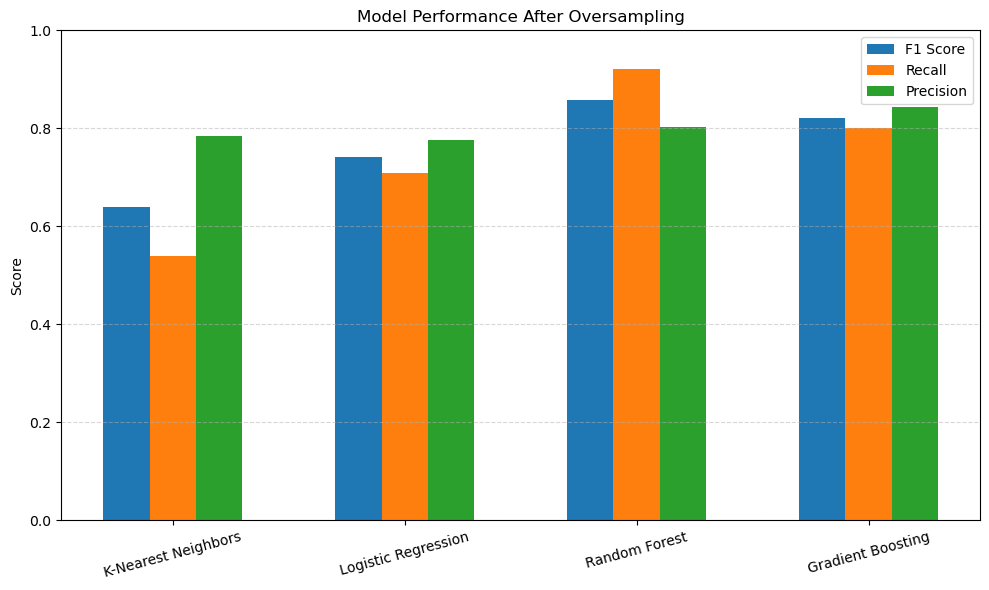

In [ ]:
# Define model performance metrics (post-oversampling)
model_metrics = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6387, 0.7407, 0.8581, 0.8218],
    "Recall": [0.5390, 0.7092, 0.9220, 0.8014],
    "Precision": [0.7835, 0.7752, 0.8025, 0.8433]
}


# Create DataFrame
df_metrics = pd.DataFrame(model_metrics)

# Set figure size
plt.figure(figsize=(10, 6))

# Bar width and positions
bar_width = 0.2
x = range(len(df_metrics["Model"]))

# Plot each metric
plt.bar([i - bar_width for i in x], df_metrics["F1 Score"], width=bar_width, label="F1 Score")
plt.bar(x, df_metrics["Recall"], width=bar_width, label="Recall")
plt.bar([i + bar_width for i in x], df_metrics["Precision"], width=bar_width, label="Precision")

# Customize the plot
plt.xticks(x, df_metrics["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Model Performance After Oversampling")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

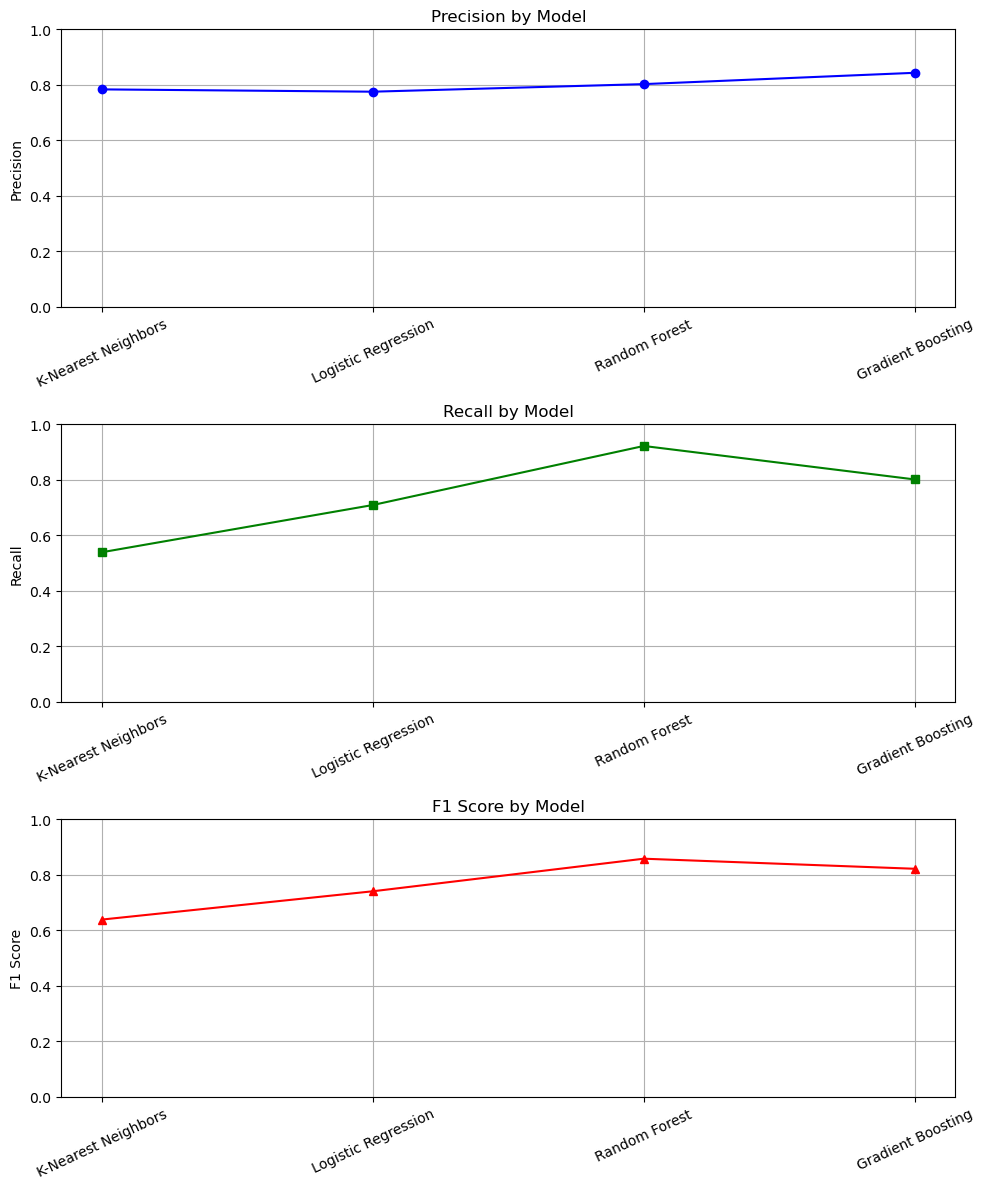

In [ ]:
import matplotlib.pyplot as plt

# Your data
data = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6387, 0.7407, 0.8581, 0.8218],
    "Recall": [0.5390, 0.7092, 0.9220, 0.8014],
    "Precision": [0.7835, 0.7752, 0.8025, 0.8433]
}

models = data["Model"]

# Create subplots (3 rows, 1 column)
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# Precision plot
axs[0].plot(models, data["Precision"], marker='o', color='blue')
axs[0].set_title('Precision by Model')
axs[0].set_ylabel('Precision')
axs[0].set_ylim(0, 1)
axs[0].grid(True)

# Recall plot
axs[1].plot(models, data["Recall"], marker='s', color='green')
axs[1].set_title('Recall by Model')
axs[1].set_ylabel('Recall')
axs[1].set_ylim(0, 1)
axs[1].grid(True)

# F1 Score plot
axs[2].plot(models, data["F1 Score"], marker='^', color='red')
axs[2].set_title('F1 Score by Model')
axs[2].set_ylabel('F1 Score')
axs[2].set_ylim(0, 1)
axs[2].grid(True)

# Rotate x-axis labels for readability
for ax in axs:
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=25)

plt.tight_layout()
plt.show()

### Undersampling

In [ ]:
train

,status of checking account,duration in month,credit history,purpose,credit amount,savings account/bonds,present employment since,installment rate in percentage,personal status and sex,other debtors / guarantors,...,property,age,other installment plans,housing,number of existing credits,job,no of people being liable,telephone,foreign worker,class
0,0.333333,1.000000,0.00,0.888889,0.362386,0.25,1.00,0.666667,0.000000,0.0,...,0.000000,0.785714,0.0,1.0,0.333333,1.0,0.0,1.0,0.0,2
1,1.000000,0.303571,0.25,0.555556,0.113844,0.25,0.25,0.333333,0.666667,0.0,...,0.333333,0.250000,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,2
2,0.000000,0.035714,0.50,0.666667,0.054253,0.75,0.50,0.333333,0.000000,0.0,...,0.666667,0.553571,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,1
3,0.000000,0.303571,1.00,0.777778,0.261527,0.00,0.50,0.000000,0.333333,0.0,...,0.666667,0.178571,1.0,1.0,0.333333,1.0,0.0,1.0,0.0,2
4,0.000000,0.142857,0.50,0.000000,0.034995,0.00,0.50,1.000000,0.333333,0.0,...,0.333333,0.035714,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0.000000,0.250000,0.75,0.777778,0.341587,0.25,1.00,0.333333,0.000000,0.0,...,0.000000,0.357143,1.0,1.0,0.333333,0.5,1.0,1.0,0.0,2
796,0.000000,0.250000,0.50,0.777778,0.132717,0.00,0.75,1.000000,0.000000,0.0,...,0.666667,0.232143,0.0,1.0,0.000000,1.0,0.0,0.0,1.0,1
797,0.000000,0.357143,0.25,0.666667,0.305601,1.00,0.50,1.000000,0.000000,0.0,...,1.000000,0.142857,0.0,1.0,0.333333,1.0,0.0,0.0,0.0,1
798,0.666667,0.142857,0.50,0.000000,0.067899,0.00,0.50,0.333333,1.000000,0.0,...,1.000000,0.107143,0.0,1.0,0.000000,1.0,0.0,1.0,0.0,2


In [ ]:
# Undersample the majority class
good_undersampled = resample(
    good,
    replace=False,                 # No replacement
    n_samples=len(bad),        # Match minority class size
    random_state=42                # For reproducibility
)

# Combine with minority class
train_under = pd.concat([bad, good_undersampled])

In [ ]:
print(train_under["class"].value_counts())

class
2    241
1    241
Name: count, dtype: int64


In [ ]:
X_train_under = train_under.drop("class", axis=1)
y_train_under = train_under["class"]

#### KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=15) #Creating an instance of the model

knn.fit(X_train_under, y_train_under) # Training the model

pred = knn.predict(X_test_transformed) #predictions for new data points

knn.score(X_test_transformed, y_test)# evaluating the model using score to get the accuracy

0.59

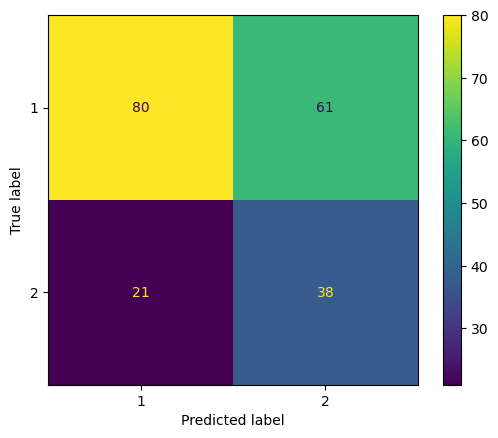

In [ ]:
confusion_matrix(y_true=y_test, y_pred=knn.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=knn.predict(X_test_transformed))

In [ ]:
print(classification_report(y_true=y_test, y_pred=knn.predict(X_test_transformed)))

              precision    recall  f1-score   support

           1       0.79      0.57      0.66       141
           2       0.38      0.64      0.48        59

    accuracy                           0.59       200
   macro avg       0.59      0.61      0.57       200
weighted avg       0.67      0.59      0.61       200



In [ ]:
# Calculate metrics
f1 = f1_score(y_test, pred)
recall = recall_score(y_test, pred)
precision = precision_score(y_test, pred)

y_proba_knn = knn.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_knn)


# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.6612
Recall       : 0.5674
Precision    : 0.7921
AUC          : 0.6504


#### Logistic regression

              precision    recall  f1-score   support

           1       0.80      0.64      0.71       141
           2       0.42      0.63      0.50        59

    accuracy                           0.64       200
   macro avg       0.61      0.63      0.61       200
weighted avg       0.69      0.64      0.65       200



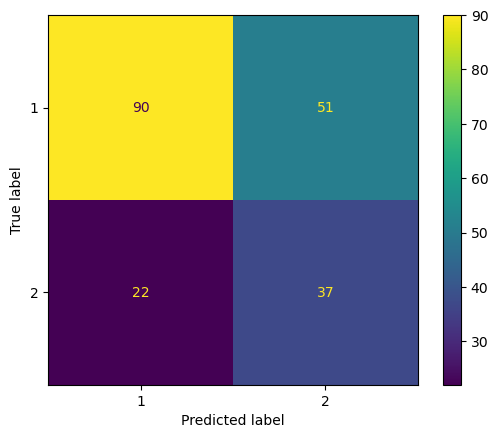

In [ ]:
# Train model
logreg = LogisticRegression(max_iter=1000)


logreg.fit(X_train_under, y_train_under)

# Predict
y_pred = logreg.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))


confusion_matrix(y_true=y_test, y_pred= logreg.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= logreg.predict(X_test_transformed))

In [ ]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_logreg = logreg.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_logreg)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.7115
Recall       : 0.6383
Precision    : 0.8036
AUC          : 0.6784


#### Random Forest

              precision    recall  f1-score   support

           1       0.88      0.71      0.79       141
           2       0.53      0.78      0.63        59

    accuracy                           0.73       200
   macro avg       0.71      0.74      0.71       200
weighted avg       0.78      0.73      0.74       200



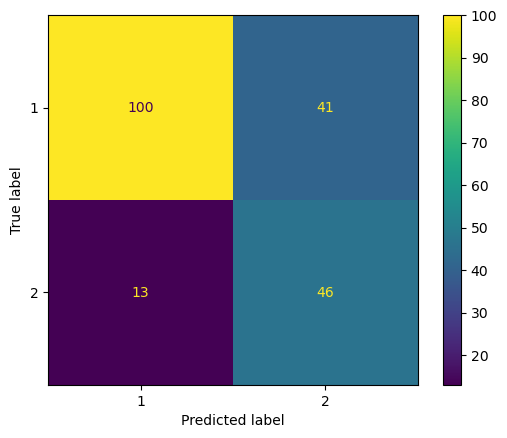

In [ ]:
# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_under, y_train_under)

# Predict
y_pred = rf_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))

In [ ]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_rf = logreg.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_rf)

# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.7874
Recall       : 0.7092
Precision    : 0.8850
AUC          : 0.6784


#### Gradient Boosting

              precision    recall  f1-score   support

           1       0.87      0.70      0.77       141
           2       0.51      0.75      0.60        59

    accuracy                           0.71       200
   macro avg       0.69      0.72      0.69       200
weighted avg       0.76      0.71      0.72       200



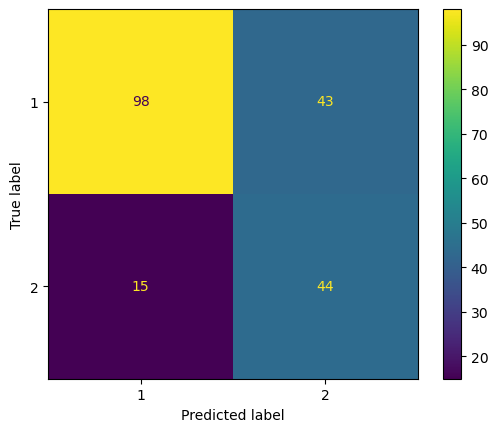

In [ ]:
# Train model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

gb_model.fit(X_train_under, y_train_under)

# Predict
y_pred = gb_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))

In [ ]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_gb = logreg.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_gb)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.7717
Recall       : 0.6950
Precision    : 0.8673
AUC          : 0.6784


#### undersampling results

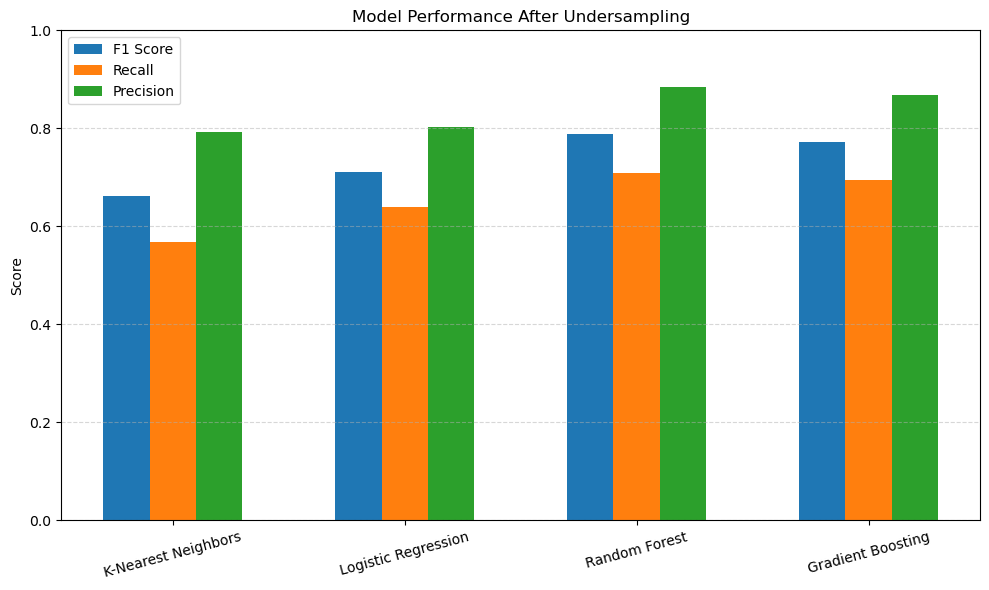

In [ ]:
# Define model performance metrics (post-undersampling)
model_metrics_under = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6612, 0.7115, 0.7874, 0.7717],
    "Recall": [0.5674, 0.6383, 0.7092, 0.6950],
    "Precision": [0.7921, 0.8036, 0.8850, 0.8673]
}

# Create DataFrame
df_under = pd.DataFrame(model_metrics_under)

# Set figure size
plt.figure(figsize=(10, 6))

# Bar width and positions
bar_width = 0.2
x = range(len(df_under["Model"]))

# Plot each metric
plt.bar([i - bar_width for i in x], df_under["F1 Score"], width=bar_width, label="F1 Score")
plt.bar(x, df_under["Recall"], width=bar_width, label="Recall")
plt.bar([i + bar_width for i in x], df_under["Precision"], width=bar_width, label="Precision")

# Customize the plot
plt.xticks(x, df_under["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Model Performance After Undersampling")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

#### SMOTE

In [ ]:
!pip install imbalanced-learn


In [ ]:
"""- **sampling_strategy** - corresponds to the ratio of the number of samples in the minority class over the number of samples in the majority class."""
smote = SMOTE(random_state = 42,sampling_strategy=1.0)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train)

#### KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=15) #Creating an instance of the model

knn.fit(X_train_resampled, y_train_resampled) # Training the model

pred = knn.predict(X_test_transformed) #predictions for new data points

knn.score(X_test_transformed, y_test)# evaluating the model using score to get the accuracy

0.615

              precision    recall  f1-score   support

           1       0.86      0.55      0.67       141
           2       0.42      0.78      0.54        59

    accuracy                           0.61       200
   macro avg       0.64      0.66      0.61       200
weighted avg       0.73      0.61      0.63       200



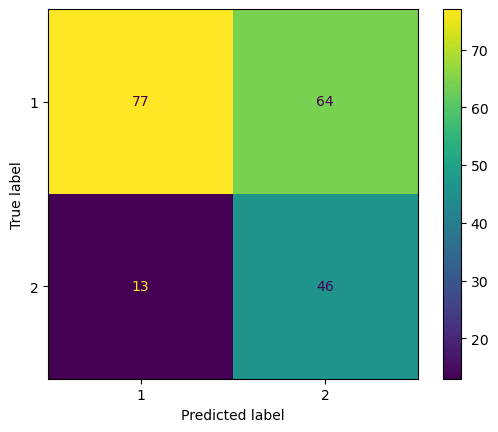

In [ ]:
confusion_matrix(y_true=y_test, y_pred=knn.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=knn.predict(X_test_transformed))

print(classification_report(y_true=y_test, y_pred=knn.predict(X_test_transformed)))

In [ ]:
# Calculate metrics
f1 = f1_score(y_test, pred)
recall = recall_score(y_test, pred)
precision = precision_score(y_test, pred)

y_proba_knn = knn.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_knn)


# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.6667
Recall       : 0.5461
Precision    : 0.8556
AUC          : 0.7209


#### Logistic regression

              precision    recall  f1-score   support

           1       0.79      0.68      0.73       141
           2       0.42      0.56      0.48        59

    accuracy                           0.65       200
   macro avg       0.60      0.62      0.61       200
weighted avg       0.68      0.65      0.66       200



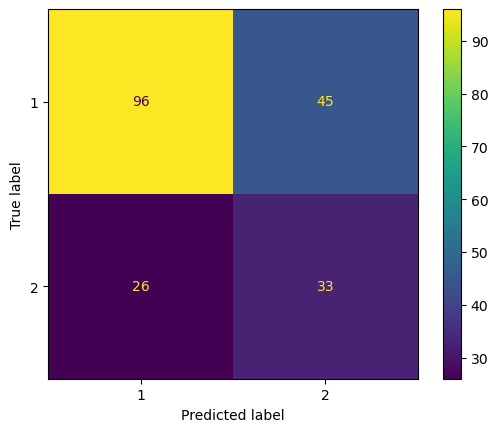

In [ ]:
# Train model
logreg = LogisticRegression(max_iter=1000)


logreg.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred = logreg.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))


confusion_matrix(y_true=y_test, y_pred= logreg.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= logreg.predict(X_test_transformed))

In [ ]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_logreg = logreg.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_logreg)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.7300
Recall       : 0.6809
Precision    : 0.7869
AUC          : 0.6780


#### Random Forest

              precision    recall  f1-score   support

           1       0.80      0.89      0.85       141
           2       0.65      0.47      0.55        59

    accuracy                           0.77       200
   macro avg       0.73      0.68      0.70       200
weighted avg       0.76      0.77      0.76       200



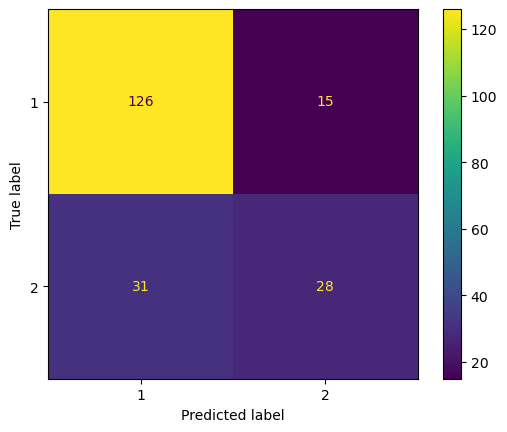

In [ ]:
# Train model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred = rf_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= rf_model.predict(X_test_transformed))

In [ ]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_rf = logreg.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_rf)

# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.8456
Recall       : 0.8936
Precision    : 0.8025
AUC          : 0.6780


#### Gradient Boosting

              precision    recall  f1-score   support

           1       0.82      0.87      0.84       141
           2       0.63      0.56      0.59        59

    accuracy                           0.78       200
   macro avg       0.73      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200



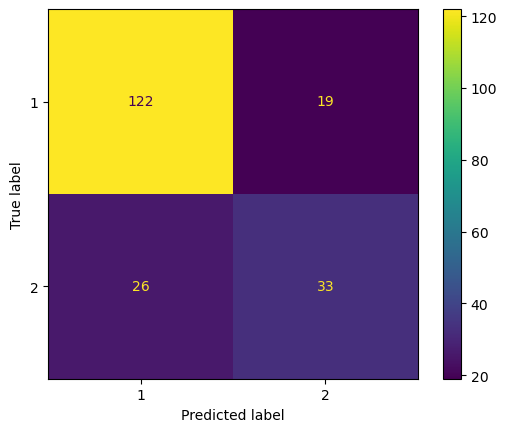

In [ ]:
# Train model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

gb_model.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred = gb_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
confusion_matrix(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred= gb_model.predict(X_test_transformed))

In [ ]:
# Calculate metrics
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_proba_gb = logreg.predict_proba(X_test_transformed)[:, 1]
auc = roc_auc_score(y_test, y_proba_gb)
# Display results
print(f"F1 Score     : {f1:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"AUC          : {auc:.4f}")

F1 Score     : 0.8443
Recall       : 0.8652
Precision    : 0.8243
AUC          : 0.6780


#### SMOTE results

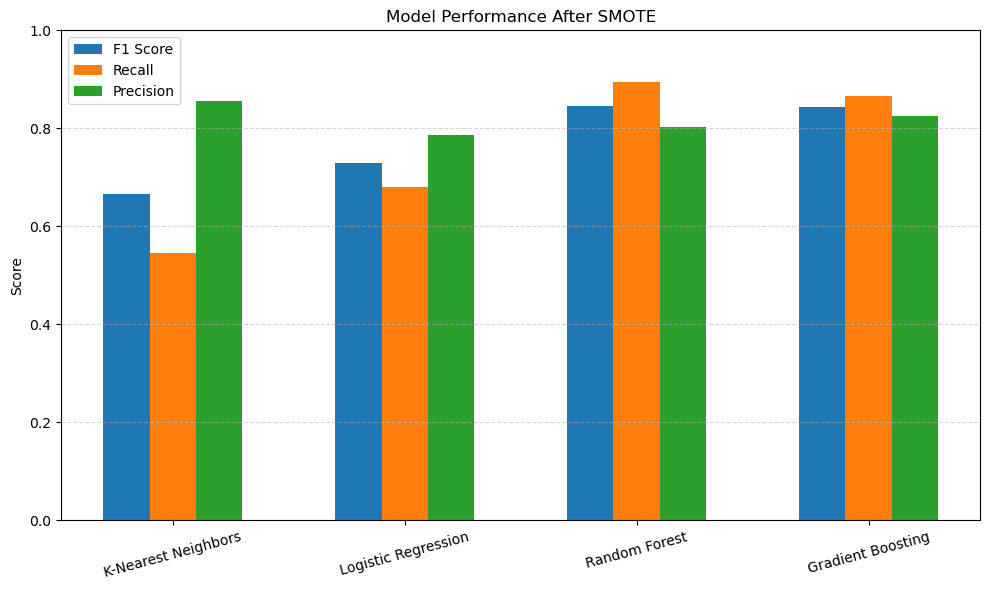

In [ ]:
# Define model performance metrics (post-SMOTE)
model_metrics_smote = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6667, 0.7300, 0.8456, 0.8443],
    "Recall": [0.5461, 0.6809, 0.8936, 0.8652],
    "Precision": [0.8556, 0.7869, 0.8025, 0.8243]
}

# Create DataFrame
df_smote = pd.DataFrame(model_metrics_smote)

# Set figure size
plt.figure(figsize=(10, 6))

# Bar width and positions
bar_width = 0.2
x = range(len(df_smote["Model"]))

# Plot each metric
plt.bar([i - bar_width for i in x], df_smote["F1 Score"], width=bar_width, label="F1 Score")
plt.bar(x, df_smote["Recall"], width=bar_width, label="Recall")
plt.bar([i + bar_width for i in x], df_smote["Precision"], width=bar_width, label="Precision")

# Customize the plot
plt.xticks(x, df_smote["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Model Performance After SMOTE")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

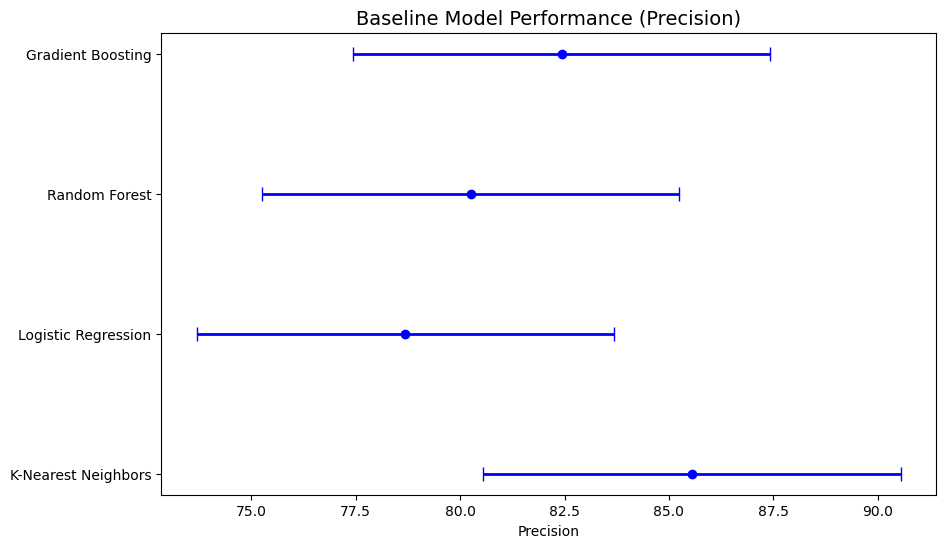

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define model performance metrics (post-oversampling)
model_metrics_smote = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6667, 0.7300, 0.8456, 0.8443],
    "Recall": [0.5461, 0.6809, 0.8936, 0.8652],
    "Precision": [0.8556, 0.7869, 0.8025, 0.8243]
}

# Create DataFrame
df_smote = pd.DataFrame(model_metrics_smote)

# Choose metric to plot
metric = "Precision"

# Mean values (convert to %)
means = df_smote[metric].values * 100
labels = df_smote["Model"].values

# Fake symmetric error bars (±5 percentage points)
# must be non-negative, so just use a constant width
error_width = np.full_like(means, 5.0)  
errors = [error_width, error_width]  

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(
    means,
    labels,
    xerr=errors,
    fmt='o',
    color='blue',
    ecolor='blue',
    elinewidth=2,
    capsize=5
)

ax.set_xlabel(f"{metric}")
ax.set_title(f"Baseline Model Performance ({metric})", fontsize=14, weight="regular")

plt.show()

#### Grid search

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'subsample': 0.7, 'n_estimators': 400, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_depth': 6, 'learning_rate': 0.18}
              precision    recall  f1-score   support

           1       0.81      0.91      0.86       141
           2       0.70      0.47      0.57        59

    accuracy                           0.79       200
   macro avg       0.75      0.69      0.71       200
weighted avg       0.77      0.79      0.77       200

Confusion Matrix:
 [[129  12]
 [ 31  28]]


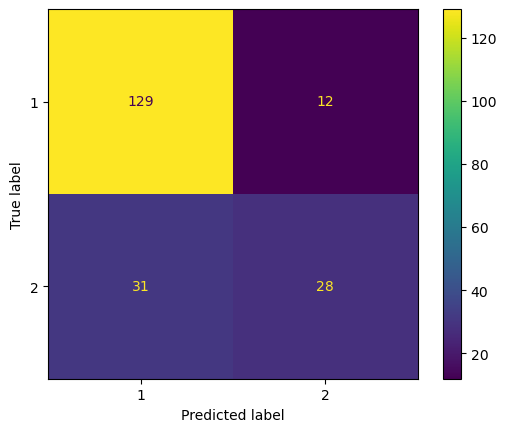

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Base model
gb_model = GradientBoostingClassifier(random_state=42)

# Hyperparameter search space
param_dist = {
    "n_estimators": np.arange(50, 500, 50),
    "learning_rate": np.linspace(0.01, 0.3, 30),
    "max_depth": np.arange(2, 10),
    "min_samples_split": np.arange(2, 20),
    "min_samples_leaf": np.arange(1, 20),
    "subsample": np.linspace(0.5, 1.0, 6)
}

# Randomized Search
random_search = RandomizedSearchCV(
    gb_model,
    param_distributions=param_dist,
    n_iter=50,   # number of random parameter combinations
    cv=3,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Fit on training data
random_search.fit(X_train_over, y_train_over)

print("Best Parameters:", random_search.best_params_)
best_model = random_search.best_estimator_

# Predict with best model
y_pred = best_model.predict(X_test_transformed)

# Evaluate
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


#### Comparing all last models

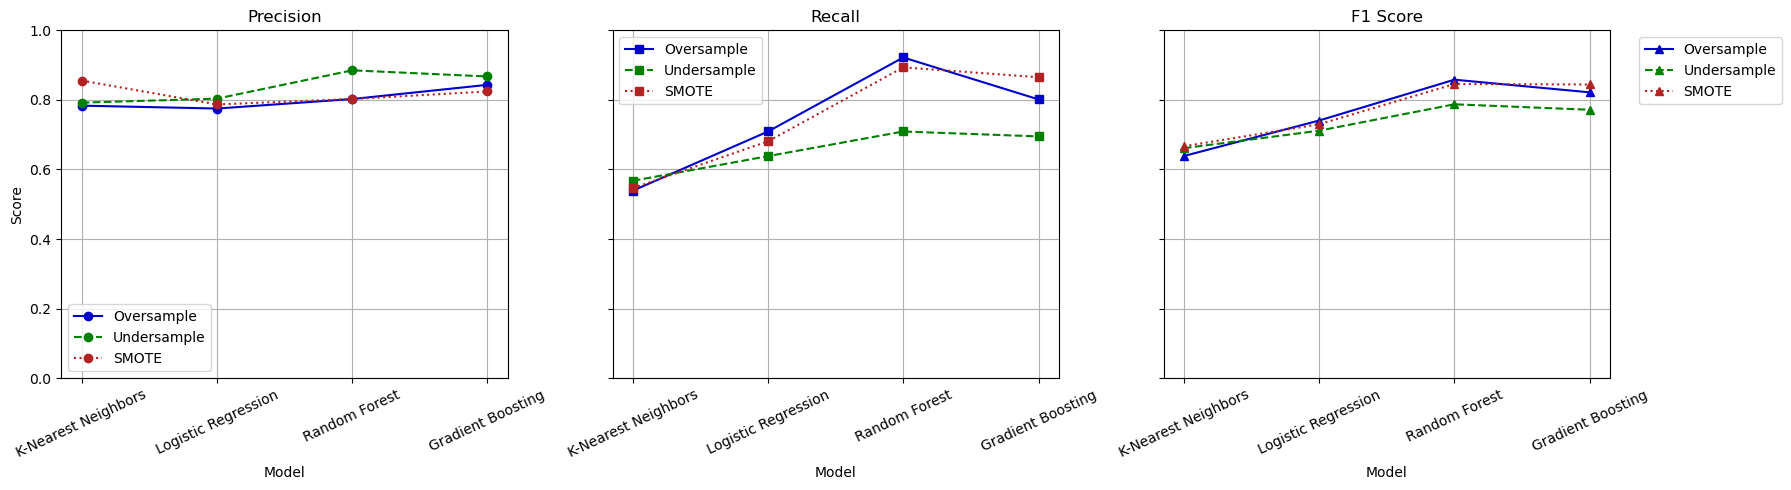

In [ ]:
import matplotlib.pyplot as plt

# Original / Oversampling data
oversample = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6387, 0.7407, 0.8581, 0.8218],
    "Recall": [0.5390, 0.7092, 0.9220, 0.8014],
    "Precision": [0.7835, 0.7752, 0.8025, 0.8433]
}

# Undersampling data
undersample = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6612, 0.7115, 0.7874, 0.7717],
    "Recall": [0.5674, 0.6383, 0.7092, 0.6950],
    "Precision": [0.7921, 0.8036, 0.8850, 0.8673]
}

# SMOTE data
smote = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6667, 0.7300, 0.8456, 0.8443],
    "Recall": [0.5461, 0.6809, 0.8936, 0.8652],
    "Precision": [0.8556, 0.7869, 0.8025, 0.8243]
}

models = oversample["Model"]

# Create horizontal subplots (1 row, 3 columns)
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Plot Precision
axs[0].plot(models, oversample["Precision"], marker='o', linestyle='-', color='mediumblue', label='Oversample')
axs[0].plot(models, undersample["Precision"], marker='o', linestyle='--', color='green', label='Undersample')
axs[0].plot(models, smote["Precision"], marker='o', linestyle=':', color='firebrick', label='SMOTE')
axs[0].set_title('Precision')
axs[0].set_xlabel('Model')
axs[0].set_ylabel('Score')
axs[0].set_ylim(0, 1)
axs[0].grid(True)
axs[0].tick_params(axis='x', rotation=25)
axs[0].legend()

# Plot Recall
axs[1].plot(models, oversample["Recall"], marker='s', linestyle='-', color='mediumblue', label='Oversample')
axs[1].plot(models, undersample["Recall"], marker='s', linestyle='--', color='green', label='Undersample')
axs[1].plot(models, smote["Recall"], marker='s', linestyle=':', color='firebrick', label='SMOTE')
axs[1].set_title('Recall')
axs[1].set_xlabel('Model')
axs[1].grid(True)
axs[1].tick_params(axis='x', rotation=25)
axs[1].legend()

# Plot F1 Score
axs[2].plot(models, oversample["F1 Score"], marker='^', linestyle='-', color='mediumblue', label='Oversample')
axs[2].plot(models, undersample["F1 Score"], marker='^', linestyle='--', color='green', label='Undersample')
axs[2].plot(models, smote["F1 Score"], marker='^', linestyle=':', color='firebrick', label='SMOTE')
axs[2].set_title('F1 Score')
axs[2].set_xlabel('Model')
axs[2].grid(True)
axs[2].tick_params(axis='x', rotation=25)
axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


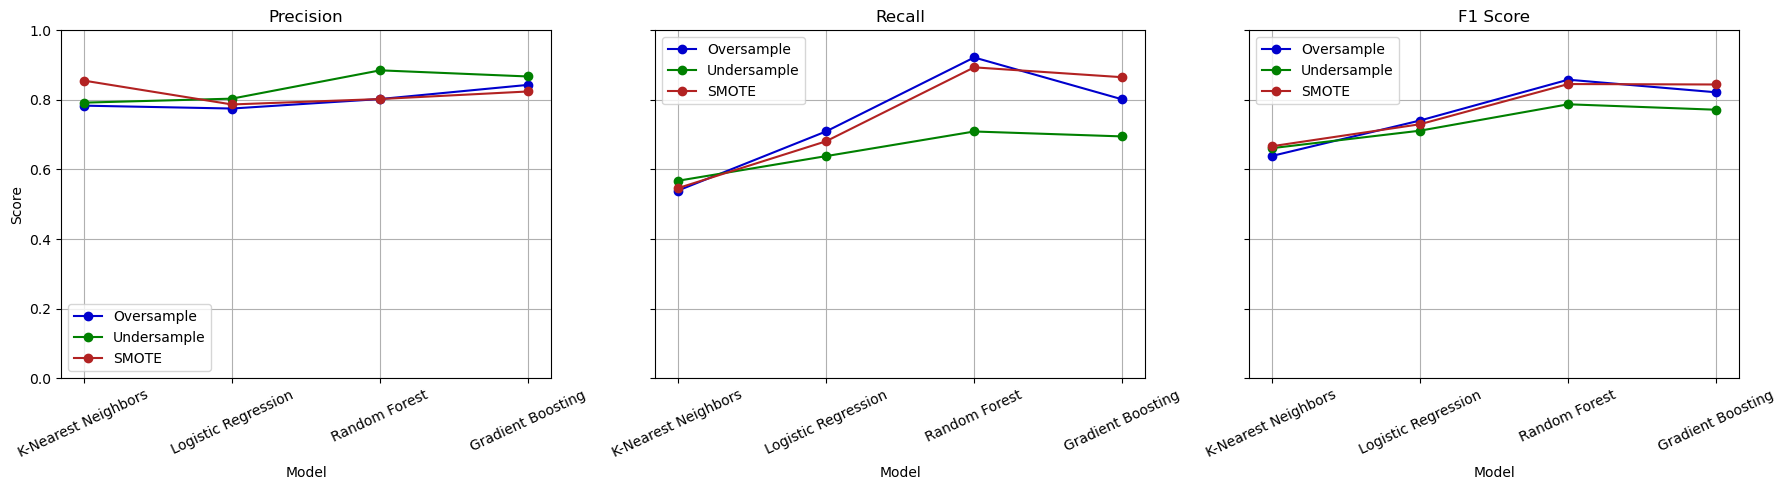

In [ ]:
import matplotlib.pyplot as plt

# Data
oversample = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6387, 0.7407, 0.8581, 0.8218],
    "Recall": [0.5390, 0.7092, 0.9220, 0.8014],
    "Precision": [0.7835, 0.7752, 0.8025, 0.8433]
}

undersample = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6612, 0.7115, 0.7874, 0.7717],
    "Recall": [0.5674, 0.6383, 0.7092, 0.6950],
    "Precision": [0.7921, 0.8036, 0.8850, 0.8673]
}

smote = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6667, 0.7300, 0.8456, 0.8443],
    "Recall": [0.5461, 0.6809, 0.8936, 0.8652],
    "Precision": [0.8556, 0.7869, 0.8025, 0.8243]
}

models = oversample["Model"]

# Horizontal subplots (1 row, 3 columns)
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Precision plot
axs[0].plot(models, oversample["Precision"], marker='o', linestyle='-', color='mediumblue', label='Oversample')
axs[0].plot(models, undersample["Precision"], marker='o', linestyle='-', color='green', label='Undersample')
axs[0].plot(models, smote["Precision"], marker='o', linestyle='-', color='firebrick', label='SMOTE')
axs[0].set_title('Precision')
axs[0].set_xlabel('Model')
axs[0].set_ylabel('Score')
axs[0].set_ylim(0, 1)
axs[0].grid(True)
axs[0].tick_params(axis='x', rotation=25)
axs[0].legend()

# Recall plot
axs[1].plot(models, oversample["Recall"], marker='o', linestyle='-', color='mediumblue', label='Oversample')
axs[1].plot(models, undersample["Recall"], marker='o', linestyle='-', color='green', label='Undersample')
axs[1].plot(models, smote["Recall"], marker='o', linestyle='-', color='firebrick', label='SMOTE')
axs[1].set_title('Recall')
axs[1].set_xlabel('Model')
axs[1].grid(True)
axs[1].tick_params(axis='x', rotation=25)
axs[1].legend()

# F1 Score plot
axs[2].plot(models, oversample["F1 Score"], marker='o', linestyle='-', color='mediumblue', label='Oversample')
axs[2].plot(models, undersample["F1 Score"], marker='o', linestyle='-', color='green', label='Undersample')
axs[2].plot(models, smote["F1 Score"], marker='o', linestyle='-', color='firebrick', label='SMOTE')
axs[2].set_title('F1 Score')
axs[2].set_xlabel('Model')
axs[2].grid(True)
axs[2].tick_params(axis='x', rotation=25)
axs[2].legend()

plt.tight_layout()
plt.show()


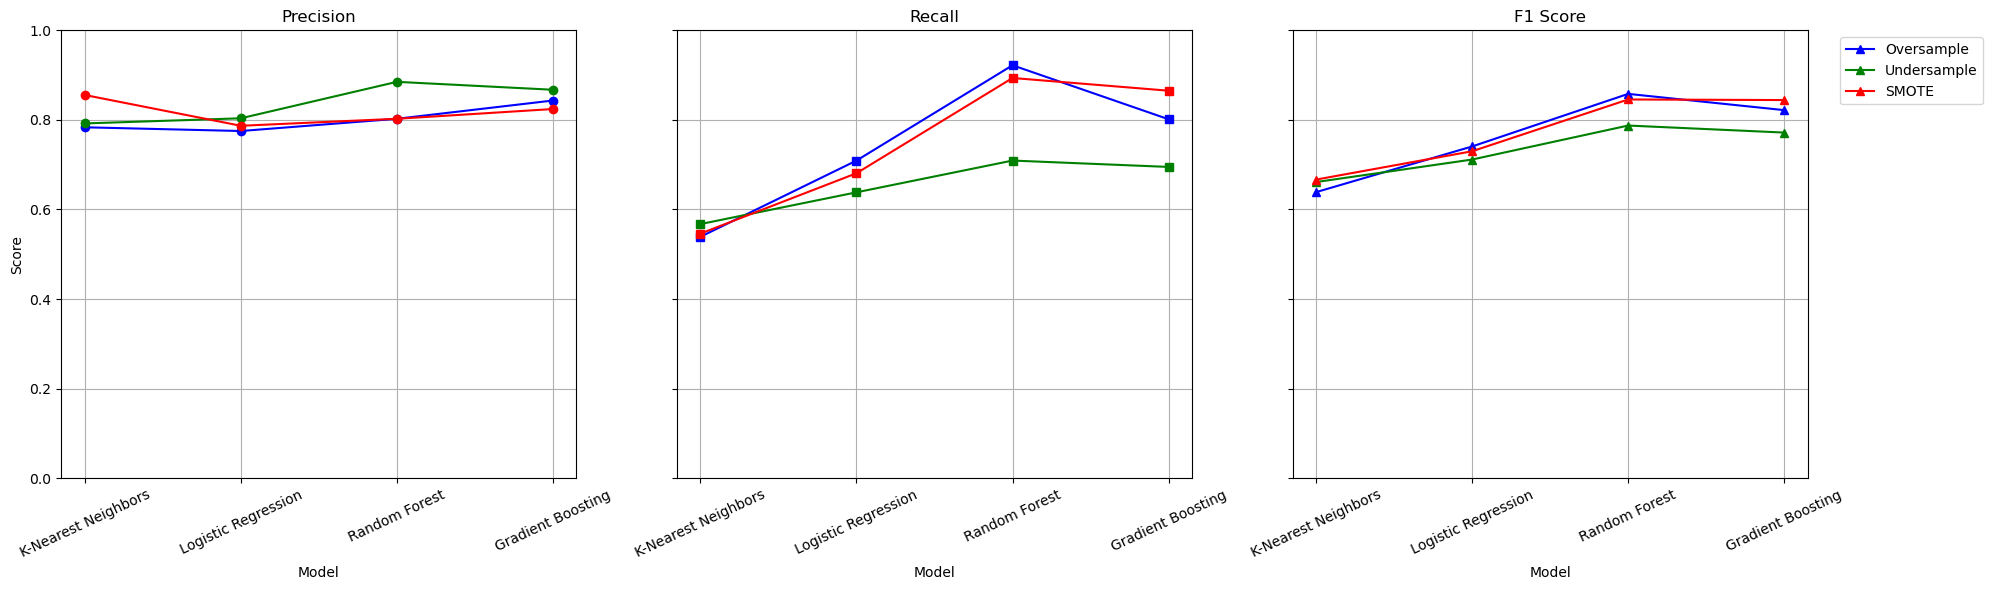

In [ ]:
import matplotlib.pyplot as plt

# Data
oversample = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6387, 0.7407, 0.8581, 0.8218],
    "Recall": [0.5390, 0.7092, 0.9220, 0.8014],
    "Precision": [0.7835, 0.7752, 0.8025, 0.8433]
}

undersample = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6612, 0.7115, 0.7874, 0.7717],
    "Recall": [0.5674, 0.6383, 0.7092, 0.6950],
    "Precision": [0.7921, 0.8036, 0.8850, 0.8673]
}

smote = {
    "Model": ["K-Nearest Neighbors", "Logistic Regression", "Random Forest", "Gradient Boosting"],
    "F1 Score": [0.6667, 0.7300, 0.8456, 0.8443],
    "Recall": [0.5461, 0.6809, 0.8936, 0.8652],
    "Precision": [0.8556, 0.7869, 0.8025, 0.8243]
}

models = oversample["Model"]

# Horizontal subplots (1 row, 3 columns)
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# Precision plot
axs[0].plot(models, oversample["Precision"], marker='o', linestyle='-', color='blue', label='Oversample')
axs[0].plot(models, undersample["Precision"], marker='o', linestyle='-', color='green', label='Undersample')
axs[0].plot(models, smote["Precision"], marker='o', linestyle='-', color='red', label='SMOTE')
axs[0].set_title('Precision')
axs[0].set_xlabel('Model')
axs[0].set_ylabel('Score')
axs[0].set_ylim(0, 1)
axs[0].grid(True)
axs[0].tick_params(axis='x', rotation=25)

# Recall plot
axs[1].plot(models, oversample["Recall"], marker='s', linestyle='-', color='blue', label='Oversample')
axs[1].plot(models, undersample["Recall"], marker='s', linestyle='-', color='green', label='Undersample')
axs[1].plot(models, smote["Recall"], marker='s', linestyle='-', color='red', label='SMOTE')
axs[1].set_title('Recall')
axs[1].set_xlabel('Model')
axs[1].grid(True)
axs[1].tick_params(axis='x', rotation=25)

# F1 Score plot
axs[2].plot(models, oversample["F1 Score"], marker='^', linestyle='-', color='blue', label='Oversample')
axs[2].plot(models, undersample["F1 Score"], marker='^', linestyle='-', color='green', label='Undersample')
axs[2].plot(models, smote["F1 Score"], marker='^', linestyle='-', color='red', label='SMOTE')
axs[2].set_title('F1 Score')
axs[2].set_xlabel('Model')
axs[2].grid(True)
axs[2].tick_params(axis='x', rotation=25)
axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


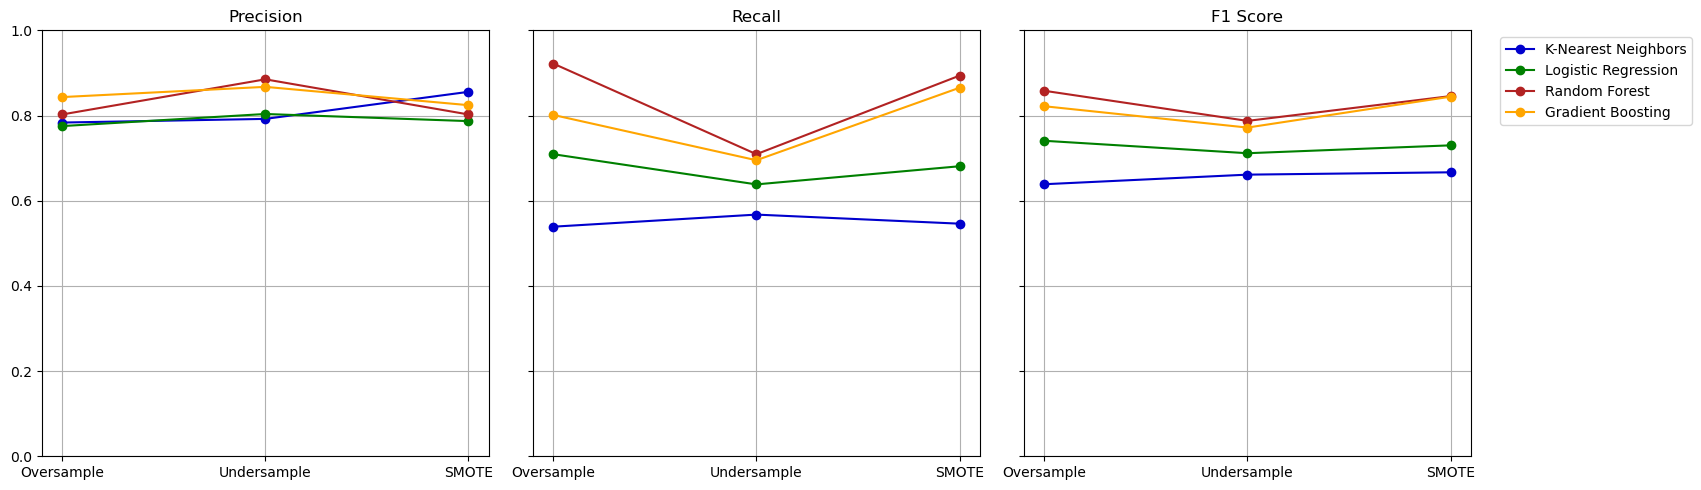

In [74]:
import matplotlib.pyplot as plt

# Data reformatted into dict of dicts for easier plotting
metrics = {
    "Oversample": {
        "K-Nearest Neighbors": {"Precision": 0.7835, "Recall": 0.5390, "F1 Score": 0.6387},
        "Logistic Regression": {"Precision": 0.7752, "Recall": 0.7092, "F1 Score": 0.7407},
        "Random Forest": {"Precision": 0.8025, "Recall": 0.9220, "F1 Score": 0.8581},
        "Gradient Boosting": {"Precision": 0.8433, "Recall": 0.8014, "F1 Score": 0.8218},
    },
    "Undersample": {
        "K-Nearest Neighbors": {"Precision": 0.7921, "Recall": 0.5674, "F1 Score": 0.6612},
        "Logistic Regression": {"Precision": 0.8036, "Recall": 0.6383, "F1 Score": 0.7115},
        "Random Forest": {"Precision": 0.8850, "Recall": 0.7092, "F1 Score": 0.7874},
        "Gradient Boosting": {"Precision": 0.8673, "Recall": 0.6950, "F1 Score": 0.7717},
    },
    "SMOTE": {
        "K-Nearest Neighbors": {"Precision": 0.8556, "Recall": 0.5461, "F1 Score": 0.6667},
        "Logistic Regression": {"Precision": 0.7869, "Recall": 0.6809, "F1 Score": 0.7300},
        "Random Forest": {"Precision": 0.8025, "Recall": 0.8936, "F1 Score": 0.8456},
        "Gradient Boosting": {"Precision": 0.8243, "Recall": 0.8652, "F1 Score": 0.8443},
    }
}

resampling_methods = list(metrics.keys())
models = list(metrics["Oversample"].keys())
colors = ["mediumblue", "green", "firebrick", "orange"]  # one color per model
markers = ['o', 'o', 'o', 'o']  # different marker per model

# Create horizontal subplots (1 row, 3 columns)
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Metrics to plot
metric_names = ["Precision", "Recall", "F1 Score"]

for i, metric in enumerate(metric_names):
    for model, color, marker in zip(models, colors, markers):
        axs[i].plot(
            resampling_methods,
            [metrics[res][model][metric] for res in resampling_methods],
            marker=marker,
            linestyle='-',
            label=model,
            color=color
        )
    axs[i].set_title(metric)
    axs[i].set_ylim(0, 1)
    axs[i].grid(True)

# Add a single legend for the whole figure
handles, labels = axs[0].get_legend_handles_labels()
axs[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0.05, 0, 1, 1])  # leave space on left for legend
plt.show()


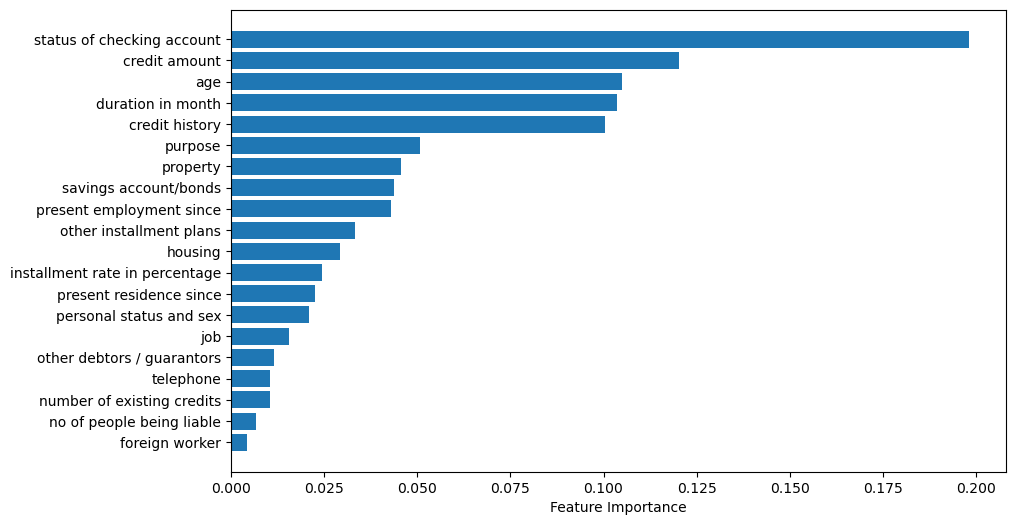

In [ ]:
# Get importances
importances = rf.feature_importances_
feature_names = X.columns

# Plot
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df["Feature"], feat_imp_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.show()

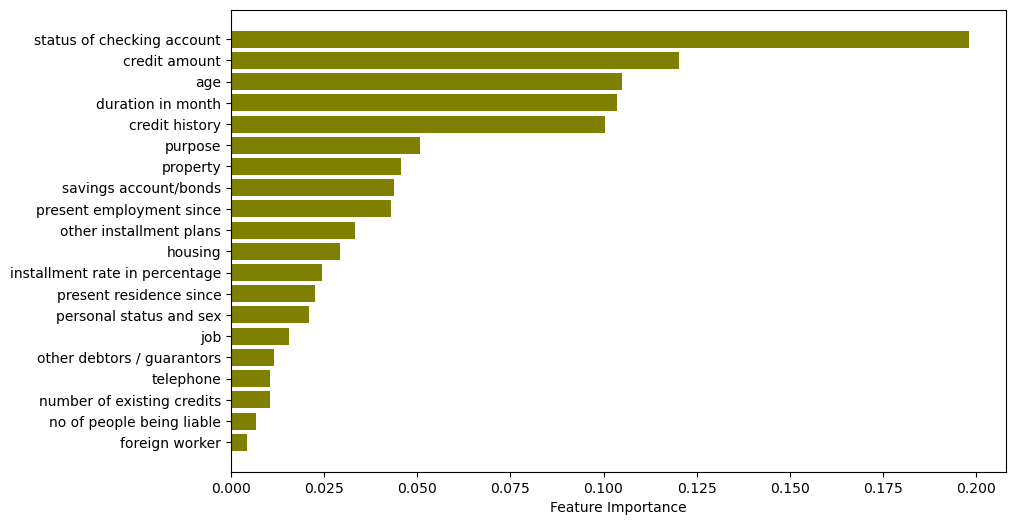

In [82]:
# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df["Feature"], feat_imp_df["Importance"], color="olive")
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.show()